# Business Case: Scaler Clustering
## Grouping learners based on backgrounds for more personalized Learning...
### Context
Scaler is an online tech-versity offering intensive computer science & Data Science courses through live classes delivered by tech leaders and subject matter experts. The meticulously structured program enhances the skills of software professionals by offering a modern curriculum with exposure to the latest technologies. It is a product by InterviewBit.

Scaler, as an emerging tech-versity, endeavors to provide world-class education in computer science & data science domains.A significant challenge for Scaler is understanding the diverse backgrounds of its learners, especially in terms of their current roles, companies, and experience.




>**Problem Type:** `Unsupervised Learning (Clustering)`

### Problem Statement:

 **Clustering similar learners helps in customizing the learning experience, thereby
increasing retention and satisfaction.**

As a data scientist with the analytics vertical of Scaler, focusing on `profiling the best companies and job positions` to work for from the Scaler database. You are provided with the information for a segment of learners and tasked to `cluster them on the basis of their job profile, company, and other features`. Ideally, these clusters should have similar characteristics.

 ### How we do it:
 - Analyzing the vast data of learners can uncover patterns in their professional
 backgrounds and preferences. This allows Scaler to make tailored content
 recommendations and provide specialized mentorship.
 - By leveraging data science and unsupervised learning, particularly clustering
 techniques, Scaler can group learners with similar profiles, aiding in delivering a
 more personalized learning journey.

### Resources: 
- `Unnamed 0` - Index of the dataset
- `Email_hash` - Anonymised Personal Identifiable Information (PII)
- `Company_hash` - This represents an anonymized identifier for the company, which is the current employer of the learner.
- `orgyear` -  Represents the year the learner began employment at the current company.
- `CTC` - Current CTC
- `Job_position` - Job profile in the company
- `CTC_updated_year` - Year in which CTC got updated (Yearly increments, Promotions)

### Concepts Used: 
- PCA, Tsne, Hypothesis testing, correlation(pearson/spearman), EDA, plotly, kmeans, kmean++, DBSCAN, hirarchial.
- Note: Above concepts are currently assumptions, might add/remove later.

### Scaler business Case review by suraaj Hasija
- This is very bad dataset
- Get the stats of ctc at company level( use group by and descirbe)
- And job position level
- 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
original_data= pd.read_csv("scaler_clustering.csv",index_col= 0) # setting the first column as the index
df = original_data.copy(deep = True) # creating deep copy to play with data while keeping original intact.
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,Other,2020.0
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,FullStack Engineer,2019.0
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,Backend Engineer,2020.0
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,Backend Engineer,2019.0
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,FullStack Engineer,2019.0


## Basic understading of the Dataset
- shape (No. of rows and columns)
- Data types (Numeric, Categorical, date/time)
- Nulls, duplicates, outliers, inconsistent formats
- Summarizing the data understanding

In [3]:
# data shape
print(f"Rows in the dataset: {df.shape[0]}")
print(f"Columns in the dataset: {df.shape[1]}")

Rows in the dataset: 205843
Columns in the dataset: 6


In [4]:
# verify column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205843 entries, 0 to 206922
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   company_hash      205799 non-null  object 
 1   email_hash        205843 non-null  object 
 2   orgyear           205757 non-null  float64
 3   ctc               205843 non-null  int64  
 4   job_position      153279 non-null  object 
 5   ctc_updated_year  205843 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 11.0+ MB


In [5]:
# Find duplicate rows
print("Duplicated records: ",df.duplicated().sum())

Duplicated records:  34


In [6]:
df.drop_duplicates(inplace=True)
print("Duplicated records: ",df.duplicated().sum())

Duplicated records:  0


In [7]:
# Null values
print("Null count in each column")
df.isna().sum()

Null count in each column


company_hash           44
email_hash              0
orgyear                86
ctc                     0
job_position        52548
ctc_updated_year        0
dtype: int64

In [8]:
# descritive statistics of numerical columns
df.describe()

,orgyear,ctc,ctc_updated_year
count,205723.000000,2.058090e+05,205809.000000
mean,2014.882264,2.271862e+06,2019.628272
std,63.576352,1.180187e+07,1.325187
min,0.000000,2.000000e+00,2015.000000
25%,2013.000000,5.300000e+05,2019.000000
50%,2016.000000,9.500000e+05,2020.000000
75%,2018.000000,1.700000e+06,2021.000000
max,20165.000000,1.000150e+09,2021.000000


- orgyear is definitely wrong with years which is 0 and 20165 - need to clean

In [9]:
def column_summary(data, col, uni_len=13):
    """
    Column Summarizer Utility
    
    Displays key statistics for column in the DataFrame:
    - Column name and data type
    - Null value count and percentage
    - Number of unique values
    - Value counts (if column is categorical or has unique values <= uni_lens)
    
    Parameters:
    - data: Pandas DataFrame
    - col: Column name (string)
    - uni_lens: Threshold for displaying value counts (int)
    """
    
    print("--" * 40)
    print(f"🔹 Column Name       : {col}")
    print(f"🔸 Data Type         : {data[col].dtype}")
    
    total_null = data[col].isnull().sum()
    null_percent = (total_null / len(data)) * 100
    print(f"❌ Total Null Values : {total_null} ({null_percent:.2f}%)")
    
    unique_vals = data[col].nunique()
    print(f"🔢 Unique Values     : {unique_vals}")
    
    # Display unique values and value counts if categorical or low cardinality
    if data[col].dtype in ('object', 'category') and unique_vals < uni_len:
        print(f"\n📊 Value Counts:\n{data[col].value_counts(dropna=False)}")

    
    # Display range (min - max) if the col is Numerical
    if data[col].dtype in ('int64', 'float64'):
        print(f"📏 Range             : {data[col].min()} - {data[col].max()}.")
        print(f"📊 Average           : {np.round(data[col].mean(),2)}")
        
    
    print("--" * 40 + "\n")


# Apply it to all columns
for col in df.columns:
    column_summary(df, col, uni_len=10)


--------------------------------------------------------------------------------
🔹 Column Name       : company_hash
🔸 Data Type         : object
❌ Total Null Values : 44 (0.02%)
🔢 Unique Values     : 37299
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
🔹 Column Name       : email_hash
🔸 Data Type         : object
❌ Total Null Values : 0 (0.00%)
🔢 Unique Values     : 153443
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
🔹 Column Name       : orgyear
🔸 Data Type         : float64
❌ Total Null Values : 86 (0.04%)
🔢 Unique Values     : 77
📏 Range             : 0.0 - 20165.0.
📊 Average           : 2014.88
--------------------------------------------------------------------------------

------------------------------------------------------------------------------

### Summarizing the data understanding:
- `Dataset`: 205843 Rows and 6 columns
- `Columns`: 3 Numerical(2 date), 3 categorical
- `Unique Learners`: 153443 Learners (Assuming unique email for each learner)
    - Need to remove the repeated email id by summing up experience and keeping the latest one
- `Missing values`: company hash(0.02%), org_year(0.04%) - Easily removable, job_position(25.53%) - Analysis and cure
- `Notes`: When we check the range there are anomolies
    - `ctc` = 2 (May be 2 lacs) | `ctc` = 1,00,01,50,000 (100crs? are you serious?)
    - `orgyear` == 0(Did he joined right after his birth or what :D, `orgyear` == 20165(immortal :o))

## Data Cleaning
- Analying importance and treating null values accordingly
- Fixing data entry issues - casing/similar meaning names
- Cleaning the orgyear, replacing with meaning full values

In [10]:
df.isna().sum()

company_hash           44
email_hash              0
orgyear                86
ctc                     0
job_position        52548
ctc_updated_year        0
dtype: int64

- Removing the null values that are less than 1% percent - You might get a doubt that they can be freshers, as ctc_updated is not null there are no freshers in the dataset.
- Just in case if i am wrong then for fresher company and orgyear and ctc_updated_year and job_position should be null.
- we can try with features with null values

In [11]:
fresher_count= df[(df["company_hash"].isna()) & (df['orgyear'].isna())]
fresher_count

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year


- By the definition of freshers we do not have them in our dataset

In [12]:
# removing the null values that are less than 1% percent

df = df.dropna(subset= ['company_hash', 'orgyear'])
df.shape

(205679, 6)

In [13]:
print("Unique job position before", df['job_position'].nunique())

df['job_position'] = df['job_position'].str.lower()

print("Unique job position after lowering string", df['job_position'].nunique())


Unique job position before 1016
Unique job position after lowering string 943


In [14]:
df['job_position'].value_counts().sort_index()

job_position
 sde 2                   1
.                        1
..                       1
.7                       1
7                        1
                        ..
worker                   1
x                        1
young professional ii    1
zomato                   1
zomato                   1
Name: count, Length: 943, dtype: int64

In [15]:
# there is lot's of bad data in the jobposition
## 1. FIRST LET'S TRY REMOVING THE SPECIAL CHARACTERS

import re
def remove_special (string):
    new_string=re.sub('[^A-Za-z ]+', '', string)
    return new_string

# CONVERTS SPECIAL CHAR INTO "". (blank)

In [16]:
df.job_position=df.job_position.apply(lambda x: remove_special(str(x)))
df.job_position=df.job_position.apply(lambda x: x.lower())
df.job_position=df.job_position.apply(lambda x: x.strip())
df['job_position'].value_counts().sort_index()

job_position
                            9
a group chat application    1
abap developer              1
account                     1
administrative clerk        1
                           ..
wordpress developer         1
worker                      1
x                           1
young professional ii       1
zomato                      2
Name: count, Length: 856, dtype: int64

In [17]:
print("Unique job position after some cleaning: ", df['job_position'].nunique())

Unique job position after some cleaning:  856


- even though the cardinality(unique names) slightly decreased but there is lot of similar names in the column.
- For now let's ignore and foucs time on next steps.

#### **Same with company hash**

In [18]:
df['company_hash'].value_counts().sort_index()

company_hash
0                                 2
0000                              1
01 ojztqsj                        2
05mz exzytvrny uqxcvnt rxbxnta    2
1                                 2
                                 ..
zyvzwt wgzohrnxzs tzsxzttqo       1
zz                                2
zzb ztdnstz vacxogqj ucn rna      2
zzgato                            1
zzzbzb                            1
Name: count, Length: 37274, dtype: int64

In [19]:
df.company_hash=df.company_hash.apply(lambda x: remove_special(str(x)))
df.company_hash=df.company_hash.apply(lambda x: x.lower())
df.company_hash=df.company_hash.apply(lambda x: x.strip())
df['company_hash'].value_counts().sort_index()

company_hash
                                                86
a                                                1
a b onttr wgqu                                   1
a j uvnxr owyggr ge tzsxzttqxzs vwvatbj vbmx     1
a ntwy ogrhnxgzo ucn rna                         2
                                                ..
zz                                               2
zz wgzztwn mya                                   1
zzb ztdnstz vacxogqj ucn rna                     2
zzgato                                           1
zzzbzb                                           1
Name: count, Length: 37182, dtype: int64

In [20]:
print("Duplicated records before: ",df.duplicated().sum())

df.drop_duplicates(inplace=True)
print("shape of dataframe after: ",df.shape)

Duplicated records before:  112
shape of dataframe after:  (205567, 6)


In [21]:
#removing rows where company or job_position is not available
df=df[ ~((df['company_hash']=='') | (df['job_position']==''))]

### Trying different Ideas
- Length of data and Unique learner are different (41077 rows has repeated emails)
- Analyzing learners who are reapeated

In [22]:
df['email_hash'].nunique()

153271

In [23]:
# calculate the difference 

df.shape[0] - df['email_hash'].nunique()

52201

In [24]:
# FREQUENCY OF LEARNER THAT HAVE MORE THAN 1 EMAIL

df['email_hash'].value_counts()[df['email_hash'].value_counts() > 1].describe()

count    41077.000000
mean         2.270808
std          0.599476
min          2.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         10.000000
Name: count, dtype: float64

In [25]:
df['email_hash'].value_counts()[df['email_hash'].value_counts() > 1].head(10)

email_hash
bbace3cc586400bbc65765bc6a16b77d8913836cfc98b77c05488f02f5714a4b    10
3e5e49daa5527a6d5a33599b238bf9bf31e85b9efa9a94f1c88c5e15a6f31378     9
6842660273f70e9aa239026ba33bfe82275d6ab0d20124021b952b5bc3d07e6c     9
298528ce3160cc761e4dc37a07337ee2e0589df251d73645aae209b010210eee     9
c0eb129061675da412b0deb15871dd06ef0d7cd86eb5f7e8cc6a20b0d1938183     8
d598d6f1fb21b45593c2afc1c2f76ae9f4cb7167156cdf93246d4192a89d8065     8
b4d5afa09bec8689017d8b29701b80d664ca37b83cb883376b2e95191320da66     8
4818edfd67ed8563dde5d083306485d91d19f4f1c95d193a1700e79dd245b75c     8
d15041f58bb01c8ee29f72e33b136e26bc32f3169a40b53d75fe7ae9cbb9a551     8
faf40195f8c58d5c7edc758cc725a762d51920da996410b80ac4a4d85c803da0     8
Name: count, dtype: int64

In [26]:
## --------------------Trying from chatgpt---------------------------##
# Number of unique emails
unique_count = df['email_hash'].nunique()

# List of unique emails (if needed)
unique_emails = df['email_hash'].unique()

print("Total emails:", len(df['email_hash']))
print("Unique emails:", unique_count)
print("Duplicate emails:", len(df['email_hash']) - unique_count)

Total emails: 205472
Unique emails: 153271
Duplicate emails: 52201


- Out of 205,472 emails, about 25% (52,201) are duplicates, while 153,271 are unique.
- Most duplicate emails occur exactly twice, with only a few outliers appearing up to 10 times.

In [27]:
# let's experiment with top values 
df[df['email_hash'] == "bbace3cc586400bbc65765bc6a16b77d8913836cfc98b77c05488f02f5714a4b"]

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year
24129,oxej ntwyzgrgsxto rxbxnta,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,2018.0,720000,nan,2020.0
46038,oxej ntwyzgrgsxto rxbxnta,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,2018.0,720000,support engineer,2020.0
72415,oxej ntwyzgrgsxto rxbxnta,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,2018.0,720000,other,2020.0
103145,oxej ntwyzgrgsxto rxbxnta,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,2018.0,720000,fullstack engineer,2020.0
118076,oxej ntwyzgrgsxto rxbxnta,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,2018.0,720000,data analyst,2020.0
121825,oxej ntwyzgrgsxto rxbxnta,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,2018.0,660000,other,2019.0
124840,oxej ntwyzgrgsxto rxbxnta,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,2018.0,660000,support engineer,2019.0
145021,oxej ntwyzgrgsxto rxbxnta,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,2018.0,660000,fullstack engineer,2019.0
153402,oxej ntwyzgrgsxto rxbxnta,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,2018.0,660000,devops engineer,2019.0
160472,oxej ntwyzgrgsxto rxbxnta,bbace3cc586400bbc65765bc6a16b77d8913836cfc98b7...,2018.0,660000,nan,2019.0


In [28]:
# since email doesn't add any value to the dataset we can remove it

# df.drop(columns=['email_hash'],inplace=True)
#dropping email will create different records and there will be no confusion for clustering

- After trying with multiple emails i have observed that orgyear is same, org is same, but different job_positions, 1 - 2 year difference in ctc_updated_year
- We can group the dataset based on email and work on that dataset

In [29]:
# Clearly the data entry has been very wrong - upper boundary
df[df['orgyear'] > 2025]['orgyear'].value_counts() # straightforward current year

orgyear
2026.0     9
2031.0     5
2029.0     5
2028.0     4
20165.0    2
2106.0     1
2107.0     1
2101.0     1
2027.0     1
2204.0     1
Name: count, dtype: int64

In [30]:
df[df['orgyear'] < 1970]['orgyear'].value_counts() # lower boundary

# trail and error, if he joined at 1971 now the person's experience will be ~54 years. which is reasonable

orgyear
0.0       17
3.0        6
91.0       3
2.0        3
1.0        2
6.0        2
5.0        2
206.0      1
4.0        1
208.0      1
209.0      1
83.0       1
38.0       1
1900.0     1
201.0      1
200.0      1
Name: count, dtype: int64

In [31]:
df[(df['orgyear'] <= 2025) & (df['orgyear'] >= 1970)]['orgyear'].describe()

count    205398.000000
mean       2015.115736
std           4.234877
min        1970.000000
25%        2013.000000
50%        2016.000000
75%        2018.000000
max        2025.000000
Name: orgyear, dtype: float64

In [32]:
median_orgyear= df[(df['orgyear'] <= 2025) & (df['orgyear'] >= 1970)]['orgyear'].median()
median_orgyear

2016.0

**Impute the `orgyear` with mean(2014) or median(2016) who entered abnormal year**

In [33]:
df['orgyear'][(df['orgyear'] > 2025) | (df['orgyear'] <= 1970)] = median_orgyear
df["orgyear"].describe()

count    205472.000000
mean       2015.116502
std           4.231808
min        1971.000000
25%        2013.000000
50%        2016.000000
75%        2018.000000
max        2025.000000
Name: orgyear, dtype: float64

## Reducing cardinality of companies and job positions

In [34]:
print("Unique companies names in the dataset ", df['company_hash'].nunique())

Unique companies names in the dataset  37179


In [35]:
## HOW? - IF THE COMPANY NAME IS APPEARED LESS THAN 5 TIMES THEN WE CONVERT IT INTO SINGLE ENTITY CALLED OTHERS.
rare_companies_appeared = df['company_hash'].value_counts()[df['company_hash'].value_counts() <= 5].reset_index()
print("Count of companies that appeared less than 5 time: ", len(rare_companies_appeared))
rare_companies_appeared.head()

Count of companies that appeared less than 5 time:  34012


,company_hash,count
0,qtnvxr ogrhnxgzo xzw,5
1,wvbuhotvx wgzogqnxhb,5
2,ntwyzxwgrgq xzaxv,5
3,rxqwntp,5
4,atcntonwg ihgnt,5


In [36]:
# MAPPING IT TO OTHERS

df['company_hash_updated']=df['company_hash'].mask(df['company_hash'].map(df['company_hash'].value_counts())<=5,'others')
print("Unique companies names in the dataset ", df['company_hash_updated'].nunique())

Unique companies names in the dataset  3168


In [37]:
df['company_hash_updated'].value_counts()

company_hash_updated
others                                                         50788
nvnv wgzohrnvzwj otqcxwto                                       8335
xzegojo                                                         5381
vbvkgz                                                          3480
zgn vuurxwvmrt vwwghzn                                          3409
                                                               ...  
rxnnrt mrvwp mggp                                                  6
exqon vbtqxwvz wgqugqvnxgz                                         6
gbzxt ogrhnxgzo                                                    6
onvzavqa wyvqntqta mrgmvr mhoxztoo otqcxwto uqxcvnt rxbxnta        6
btaxvgwtvz voxv ucn rna                                            6
Name: count, Length: 3168, dtype: int64

In [38]:
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu


## Feature Engineering - Create usefull features based on current dataset

In [39]:
# CREATE AN EXPERIENCE COLUMN BASED ON CURRENT YEAR. AS PER MEETING THIS DATASET IS ABOUT PEOPLE WHO ARE ACTIVELY WORKING

# so engineered a experience column as of 2025

df['experience'] = 2025 - df['orgyear']
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv,9.0
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta,7.0
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others,10.0
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv,8.0
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu,8.0


In [40]:
# CREATE A FUNCTION THAT CLASSIFIES TECH AND NON TECH PEOPLE

tech_key_words= ['engineer', 'developer', 'programmer', 'analyst', 'software', 'scientist', 'it', 'technology']

df["job_group"]= df['job_position'].apply(
    lambda x: "tech" if any(keyword in str(x) for keyword in tech_key_words)
    else "unknown" if str(x) == ""
    else "non_tech"
)

In [41]:
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv,9.0,non_tech
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta,7.0,tech
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others,10.0,tech
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv,8.0,tech
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu,8.0,tech


### Summary of Data Cleaning and Feature engineering
- Removed null values that are less than 0.05%
- Reduced cardinality of job_position
- Grouped data based on email(Learners)
- classified tech_non_tech based on keywords in job_position
- Null values are converted into unknown in tech_non_tech column
  
Detailed description under the cell that has been work done.

## Manual Clustering - on the basis of learner’s company, job position and years of experience

**Problem Statement 1**: Getting the 5 point summary of CTC (mean, median, max, min, count etc) on the basis of Company, Job Position, Years of Experience

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205472 entries, 0 to 206922
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   company_hash          205472 non-null  object 
 1   email_hash            205472 non-null  object 
 2   orgyear               205472 non-null  float64
 3   ctc                   205472 non-null  int64  
 4   job_position          205472 non-null  object 
 5   ctc_updated_year      205472 non-null  float64
 6   company_hash_updated  205472 non-null  object 
 7   experience            205472 non-null  float64
 8   job_group             205472 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 15.7+ MB


In [43]:
summary = (
    df.groupby(["company_hash_updated", "job_position", "experience"])["ctc"]
      .agg(
          count="count",
          avg_ctc="mean",
          std="std",
          min_ctc="min",
          q25=lambda x: x.quantile(0.25),
          median_ctc="median",
          q75=lambda x: x.quantile(0.75),
          max_ctc="max"
      )
      .reset_index()
)

summary.head()


,company_hash_updated,job_position,experience,count,avg_ctc,std,min_ctc,q25,median_ctc,q75,max_ctc
0,a ntwyzgrgsxto,android engineer,11.0,1,710000.0,NaN,710000,710000.0,710000.0,710000.0,710000
1,a ntwyzgrgsxto,backend engineer,10.0,1,600000.0,NaN,600000,600000.0,600000.0,600000.0,600000
2,a ntwyzgrgsxto,backend engineer,11.0,1,600000.0,NaN,600000,600000.0,600000.0,600000.0,600000
3,a ntwyzgrgsxto,backend engineer,12.0,1,1350000.0,NaN,1350000,1350000.0,1350000.0,1350000.0,1350000
4,a ntwyzgrgsxto,frontend engineer,9.0,2,500000.0,0.0,500000,500000.0,500000.0,500000.0,500000


**Problem Statement 2**: Merging the same with original dataset carefully and creating some flags showing learners with CTC greater than the Average of their Company’s department having same Years of Experience - Call that flag designation with values [1,2,3]

In [44]:
merged_df= df.merge(summary, on= ["company_hash_updated", "job_position", "experience"], how= 'left')
merged_df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group,count,avg_ctc,std,min_ctc,q25,median_ctc,q75,max_ctc
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv,9.0,non_tech,1,1.100000e+06,NaN,1100000,1100000.0,1100000.0,1100000.0,1100000
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta,7.0,tech,7,7.742856e+05,2.509223e+05,449999,610000.0,750000.0,900000.0,1200000
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others,10.0,tech,923,1.444876e+06,4.870455e+06,1000,500000.0,900000.0,1500000.0,100420000
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv,8.0,tech,7,1.158571e+06,4.047810e+05,700000,825000.0,1200000.0,1405000.0,1750000
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu,8.0,tech,1,1.400000e+06,NaN,1400000,1400000.0,1400000.0,1400000.0,1400000


In [45]:
merged_df.shape

(205472, 17)

In [46]:
print("Duplicates in the dataset: ", merged_df.duplicated().sum())
merged_df.drop_duplicates(inplace= True)
print("Shape of the dataset after removing the dataset" , merged_df.shape)

Duplicates in the dataset:  0
Shape of the dataset after removing the dataset (205472, 17)


In [47]:
# Create designation flag
# define = {1: "above_avg", 2: 'around_avg', 3: "below_avg"}

def get_designation(ctc, avg_ctc):
    if ctc < 0.75 * avg_ctc: # percentages so that if you are within 10% of average, that's still average
        return 3
    elif ctc > 1.25 * avg_ctc:
        return 1
    else:
        return 2

merged_df['cluster1_d_level'] =merged_df.apply(lambda x: get_designation(x['ctc'], x['avg_ctc']), axis=1)


In [48]:
merged_df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group,count,avg_ctc,std,min_ctc,q25,median_ctc,q75,max_ctc,cluster1_d_level
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv,9.0,non_tech,1,1.100000e+06,NaN,1100000,1100000.0,1100000.0,1100000.0,1100000,2
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta,7.0,tech,7,7.742856e+05,2.509223e+05,449999,610000.0,750000.0,900000.0,1200000,3
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others,10.0,tech,923,1.444876e+06,4.870455e+06,1000,500000.0,900000.0,1500000.0,100420000,1
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv,8.0,tech,7,1.158571e+06,4.047810e+05,700000,825000.0,1200000.0,1405000.0,1750000,3
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu,8.0,tech,1,1.400000e+06,NaN,1400000,1400000.0,1400000.0,1400000.0,1400000,2


**Problem statement 3**: Doing above analysis at Company & Job Position level. Name that flag Class with values [1,2,3]

In [49]:
# Group by company + job_position
group_means2 = (
    df.groupby(["company_hash_updated", "job_position"])["ctc"]
    .mean()
    .reset_index()
    .rename(columns={"ctc": "mean_ctc_jobpos"})
)

# Merge back into merged_df
merged_df2 = df.merge(group_means2, on=["company_hash_updated", "job_position"], how="left")

In [50]:
merged_df2.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group,mean_ctc_jobpos
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv,9.0,non_tech,1.085000e+06
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta,7.0,tech,9.882000e+05
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others,10.0,tech,1.980180e+06
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv,8.0,tech,1.500000e+06
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu,8.0,tech,8.466667e+05


In [51]:
# CLUSTERING CTC JOB PROFILES BASED ON COMPANY AND JOB POSITIONS TO IDENTIFY
# define = {1: "above_avg", 2: 'around_avg', 3: "below_avg"}

def get_designation(ctc, avg_ctc):
    if ctc < 0.75 * avg_ctc: # percentages so that if you are within 10% of average, that's still average
        return 3
    elif ctc > 1.25 * avg_ctc:
        return 1
    else:
        return 2

merged_df2['tier_levels'] = merged_df2.apply(lambda x: get_designation(x['ctc'], x['mean_ctc_jobpos']), axis=1)


In [52]:
merged_df2.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group,mean_ctc_jobpos,tier_levels
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv,9.0,non_tech,1.085000e+06,2
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta,7.0,tech,9.882000e+05,3
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others,10.0,tech,1.980180e+06,2
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv,8.0,tech,1.500000e+06,3
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu,8.0,tech,8.466667e+05,1


**Problem Statement 4**: Repeating the same analysis at the Company level. Name that flag Tier with values [1,2,3]

In [53]:
# Group by company + job_position
group_means3 = (
    df.groupby(["company_hash_updated"])["ctc"]
    .mean()
    .reset_index()
    .rename(columns={"ctc": "mean_ctc_cmp_level"})
)

# Merge back into merged_df
merged_df3 = df.merge(group_means3, on=["company_hash_updated"], how="left")

In [54]:
merged_df3.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group,mean_ctc_cmp_level
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv,9.0,non_tech,1.115667e+06
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta,7.0,tech,2.197334e+06
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others,10.0,tech,2.551936e+06
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv,8.0,tech,1.713929e+06
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu,8.0,tech,9.400000e+05


In [55]:
# CLUSTERING CTC BASED ON COMPANY PAY
# define = {1: "above_avg", 2: 'around_avg', 3: "below_avg"}

def get_designation(ctc, avg_ctc):
    if ctc < 0.75 * avg_ctc: # percentages so that if you are within 10% of average, that's still average
        return 3
    elif ctc > 1.25 * avg_ctc:
        return 1
    else:
        return 2

merged_df3['cmp_levels'] = merged_df3.apply(lambda x: get_designation(x['ctc'], x['mean_ctc_cmp_level']), axis=1)


In [56]:
1.25 * 2020875

2526093.75

In [57]:
9500000 - 2526093.75

6973906.25

In [58]:
pd.set_option('display.max_columns', 500)
merged_df3.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group,mean_ctc_cmp_level,cmp_levels
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv,9.0,non_tech,1.115667e+06,2
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta,7.0,tech,2.197334e+06,3
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others,10.0,tech,2.551936e+06,2
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv,8.0,tech,1.713929e+06,3
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu,8.0,tech,9.400000e+05,1


In [59]:
merged_df3.columns

Index(['company_hash', 'email_hash', 'orgyear', 'ctc', 'job_position',
       'ctc_updated_year', 'company_hash_updated', 'experience', 'job_group',
       'mean_ctc_cmp_level', 'cmp_levels'],
      dtype='object')

In [60]:
# Top 10 employees (earning more than most of the employees in the company) - Tier 1

# we need grouped df based on company that means merged_df3

merged_df3[['company_hash', 'email_hash', 'ctc','mean_ctc_cmp_level', 'job_position', 'experience', 'job_group', 'cmp_levels']][merged_df3['cmp_levels'] == 1].sort_values('ctc', ascending= False).head(10)

,company_hash,email_hash,ctc,mean_ctc_cmp_level,job_position,experience,job_group,cmp_levels
72725,whmxw rgsxwo uqxcvnt rxbxnta,29a71dd13adf6d2d497571a565bb3096cf66cb46cd1ece...,1000150000,2.551936e+06,nan,10.0,non_tech,1
117462,obvqnuqxdwgb,5b4bed51797140db4ed52018a979db1e34cee49e27b488...,255555555,4.395259e+07,nan,7.0,non_tech,1
3293,aveegaxr xzntqzvnxgzvr hzxctqoxnj,06d231f167701592a69cdd7d5c825a0f5b30f0347a4078...,250000000,2.551936e+06,nan,4.0,non_tech,1
125947,ovu,7683974378d0f5bacf95632f130a60cfa3ca39e368eec9...,200000000,2.570791e+06,nan,6.0,non_tech,1
125756,atrgxnnt,42b16d7825c41cc884176f81a8642e781a658fd9b677da...,200000000,2.367870e+06,nan,13.0,non_tech,1
126006,xzegojo,0c9c37269bd373ef507df0bc1bb318787fd895c858b74e...,200000000,1.408587e+06,nan,5.0,non_tech,1
7203,nvrtza,6b3c275643094c663a51e84196fd71dc662d40038d3294...,200000000,2.551936e+06,support engineer,9.0,tech,1
8054,zgzt,232e5b21da629a8acb3bdef7b49e57b28fc3bf64ae2687...,200000000,5.740659e+06,engineering leadership,2.0,tech,1
7354,twr,4445dc520c460188faf9a2be433400ca0bb8d8499efef6...,200000000,2.551936e+06,data analyst,9.0,tech,1
2682,utsvojontbo,ad4e0f1b79db26b5ecc4431f28335716168c2f7c07f2e8...,200000000,3.408929e+06,frontend engineer,18.0,tech,1


**Insights**:
- Several employees report extremely high CTCs (200M–1B) compared to their company averages (≈2–5M), indicating potential outliers or data entry errors.
- Despite being in non-tech roles, some candidates (e.g., whmxw rgsxwo...) show disproportionately high pay, which is unusual relative to peers.
- These are might be CEO's or quant traders or data entry mistakes

In [61]:
merged_df3[merged_df3['cmp_levels']==1][['job_position','ctc']].groupby('job_position')['ctc'].describe().sort_values(by=['count','mean'],ascending=False)[:10]

,count,mean,std,min,25%,50%,75%,max
job_position,,,,,,,,
backend engineer,6014.0,6.717968e+06,1.940670e+07,400000.0,2000000.0,3000000.0,4500000.0,2.000000e+08
nan,5528.0,1.069298e+07,3.427035e+07,200000.0,2000000.0,2950000.0,4400000.0,1.000150e+09
engineering leadership,3245.0,6.414159e+06,1.795192e+07,200000.0,2800000.0,3550000.0,4800000.0,2.000000e+08
fullstack engineer,2741.0,8.714495e+06,2.549896e+07,200000.0,1800000.0,2650000.0,4400000.0,2.000000e+08
other,1751.0,3.346909e+07,5.934838e+07,200000.0,2100000.0,3700000.0,27500000.0,2.000000e+08
frontend engineer,927.0,1.081421e+07,3.224721e+07,200000.0,1650000.0,2400000.0,4000000.0,2.000000e+08
data scientist,813.0,6.629380e+06,1.987773e+07,600000.0,2000000.0,2900000.0,4300000.0,2.000000e+08
backend architect,689.0,4.813373e+06,9.456590e+06,1000000.0,2900000.0,3670000.0,4850000.0,2.000000e+08
qa engineer,494.0,1.515620e+07,3.799690e+07,480000.0,2000000.0,3000000.0,5000000.0,2.000000e+08


In [62]:
# Top 10 employees of data science in each company earning more than their peers - Class 1
merged_df3[['company_hash', 'email_hash', 'ctc','mean_ctc_cmp_level', 'job_position', 'experience', 'job_group', 'cmp_levels']][(merged_df3['cmp_levels'] == 1) & (merged_df3['job_position'].str.contains("data scientist"))].sort_values('ctc', ascending= False).head(10)

,company_hash,email_hash,ctc,mean_ctc_cmp_level,job_position,experience,job_group,cmp_levels
52736,zgzt,268a5aa92f0b6d0c675fc9cc1e300eb0c5930a3a139a23...,200000000,5.740659e+06,data scientist,3.0,tech,1
836,mqxonrtwgzt v bvyxzaqv sqghu wgbuvzj,cda8d723438e81185d2ee8c348870a4612eea974cdb2db...,200000000,5.616465e+06,data scientist,8.0,tech,1
31242,ihvaqvnxw xzoxsyno ucn rna,bd222ea783ee372da4e0ad60fdccec0b8f37999a032025...,200000000,2.932143e+07,data scientist,10.0,tech,1
2683,ptnovvr qtnvxr rru,72ed7ced98573f71c8f95bc8b75aac4f0677e8872c6bec...,199800000,2.551936e+06,data scientist,6.0,tech,1
45143,pgnvp,ace1152ca60b6f2c62bb7c4a00bca0afd5a9bb2c297267...,150000000,1.565000e+07,data scientist,33.0,tech,1
36732,wrghaotp,a1223067ab5c4ff7fcf39ed4c053057f06090a57fc05ba...,127600000,2.819300e+07,data scientist,8.0,tech,1
1735,myvoyjvb owyggr,ee8dd42d6ea8365909147d861c7978d19f727a8075ba96...,102500000,2.551936e+06,data scientist,5.0,tech,1
143074,ptzgbt,4ddef8762b7585c6ee7b8c06834778f3aa00eb3be312b0...,100000000,2.551936e+06,data scientist,5.0,tech,1
23512,xzegsvxz xzaxv uqxcvnt rxbxnta,9ddd3b9e97841f9713b1e17a264656efdf9b6fd8ba169b...,100000000,3.688803e+06,data scientist,10.0,tech,1
13488,utqtzsg,e7722fb701c61e5cad82c39ee8bf3debe160d429b72c64...,100000000,2.551936e+06,data scientist,10.0,tech,1


In [63]:
# Bottom 10 employees of data science in each company earning less than their peers - Class 3
merged_df3[['company_hash', 'email_hash', 'ctc','mean_ctc_cmp_level', 'job_position', 'experience', 'job_group', 'cmp_levels']][(merged_df3['cmp_levels'] == 3) & (merged_df3['job_position'].str.contains("data scientist"))].sort_values('ctc').head(10)

,company_hash,email_hash,ctc,mean_ctc_cmp_level,job_position,experience,job_group,cmp_levels
193849,otjch xzw,585f7e9865dcdcaad7edf10909d796ba2c5210cde3530b...,4000,2.551936e+06,data scientist,8.0,tech,3
10810,srgmvrtast xzntrrxstzwt ge nyxzso,8001bc017fbe95541d23f5780c3edb988b7d9b2225e39e...,4000,5.895806e+05,data scientist,8.0,tech,3
8683,bxyhu wgbbhzxwvnxgz,690f6fdab1ab7514a6a9325ebd6cfe910dbf12d46b6fde...,4000,6.264615e+05,data scientist,7.0,tech,3
168048,nvrrtq ntwyzgrgsxto,05801a432a038c254972e356598ca6aa139a18c31d6611...,4000,2.551936e+06,data scientist,4.0,tech,3
50950,onhatzn,bd9c04a574090e05b366a81cdb2f3f565d0c60fa8b1647...,6000,3.705766e+06,data scientist,4.0,tech,3
136755,ovbohzs trtwnqg btwyvzxwo,e374eea75640881206a21894f69190138c2c0535277dc1...,7000,2.551936e+06,data scientist,8.0,tech,3
24062,exznqhon ogrhnxgzo ucn rna,ab2dc9db23c3104f0b6b3dbd4cdd5bfb9e5829b8b7943d...,7200,2.551936e+06,data scientist,8.0,tech,3
182913,dvcgq,287dd26e9357888e0ba2c7482764131f7bbcb1748a4f56...,7250,2.551936e+06,data scientist,6.0,tech,3
92524,wtxuvr wgqu,0dcbef1fe34438edbb39b52451378ea61ac2b84a56d919...,7500,2.551936e+06,data scientist,8.0,tech,3
9381,nvnv wgzohrnvzwj otqcxwto,3175d03fd4618eb293d6f5a1d13d42a0c79f68e9acaaa3...,7500,1.651335e+06,data scientist,5.0,tech,3


- These is really bad data set contains a lots of bad data, for example a guy who has 5 - 8 years of experience earning just 4 - 8 thousand.
- Whatever the reason may be this is not so useful data for any types of algorithms to train on.

In [64]:
merged_df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group,count,avg_ctc,std,min_ctc,q25,median_ctc,q75,max_ctc,cluster1_d_level
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv,9.0,non_tech,1,1.100000e+06,NaN,1100000,1100000.0,1100000.0,1100000.0,1100000,2
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta,7.0,tech,7,7.742856e+05,2.509223e+05,449999,610000.0,750000.0,900000.0,1200000,3
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others,10.0,tech,923,1.444876e+06,4.870455e+06,1000,500000.0,900000.0,1500000.0,100420000,1
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv,8.0,tech,7,1.158571e+06,4.047810e+05,700000,825000.0,1200000.0,1405000.0,1750000,3
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu,8.0,tech,1,1.400000e+06,NaN,1400000,1400000.0,1400000.0,1400000.0,1400000,2


In [65]:
# Top 10 employees in each company - X department - having 5/6/7 years of experience earning more than their peers - Tier 1
# for company, position, experience we use merged_df

merged_df[['email_hash', 'company_hash', 'job_position', 'experience', 'ctc','avg_ctc', 'job_group', 'cluster1_d_level']][((merged_df['experience'] >= 5) |(merged_df['experience'] <= 7)) & (merged_df['cluster1_d_level'] == 1)].sort_values('ctc', ascending=False).head(10)

,email_hash,company_hash,job_position,experience,ctc,avg_ctc,job_group,cluster1_d_level
72725,29a71dd13adf6d2d497571a565bb3096cf66cb46cd1ece...,whmxw rgsxwo uqxcvnt rxbxnta,nan,10.0,1000150000,2.147006e+06,non_tech,1
117462,5b4bed51797140db4ed52018a979db1e34cee49e27b488...,obvqnuqxdwgb,nan,7.0,255555555,1.289778e+08,non_tech,1
3293,06d231f167701592a69cdd7d5c825a0f5b30f0347a4078...,aveegaxr xzntqzvnxgzvr hzxctqoxnj,nan,4.0,250000000,7.852931e+06,non_tech,1
50429,1b7714d3fb9f4805c0564b20d775e31e1d09e752beadcc...,sggsrt,fullstack engineer,4.0,200000000,5.220000e+07,tech,1
51555,2744c7f42fd4d492fa66cb2ba5168921c444dc8611ffa2...,vwwtznhqt,nan,7.0,200000000,3.086178e+06,non_tech,1
16512,a9067f824ad20a50522d380dee74cdce7a3a6fd6467771...,vwwtznhqt,other,9.0,200000000,1.802949e+07,non_tech,1
16423,58e652d3e06d4228be0a8ac9ef8228928628299d93795f...,zxxn ntwyzgrgsxto rxbxnta,fullstack engineer,11.0,200000000,1.003000e+08,tech,1
45688,5f39783f33de6430635e8e1770cc93e9d73e40cd7ed6dd...,otre tburgjta,other,8.0,200000000,2.029670e+07,non_tech,1
45932,d6d921d5a6f8979ffbe72ddad6f77a138e6ba8ea09c888...,xtrrxuot ntwyzgrgsxto,backend engineer,12.0,200000000,2.862560e+06,tech,1
45899,47d993914804e1a737d4af1b877ebb7f6867e39134d6d7...,ntwywg egqbtqrj ntwy wgwpnvxr,backend engineer,6.0,200000000,1.765763e+06,tech,1


In [66]:
# Top 10 companies (based on their average CTC payout)

merged_df3[['company_hash', 'mean_ctc_cmp_level']].sort_values('mean_ctc_cmp_level', ascending= False).drop_duplicates().head(10)

,company_hash,mean_ctc_cmp_level
6711,xzaxvmhrro,5.374143e+07
32687,obvqnuqxdwgb,4.395259e+07
27169,ho tzsxzttqxzs wgbuvzj,4.348714e+07
129203,fgqraihvzn rrw,3.495833e+07
149089,egdwgzz,3.423250e+07
88092,omx,3.412333e+07
188350,xqgz bghznvxz,3.395833e+07
170104,ntvwy egq xzaxv,3.232771e+07
94515,nyt sqtvn wghqoto,3.215200e+07
179831,psxor,3.194560e+07


In [67]:
# Top 2 positions in every company (based on their CTC)
top2_positions = (
    merged_df2[["company_hash", "job_position", "mean_ctc_jobpos"]]
      .drop_duplicates()   # ensure one row per company-position
      .sort_values(["company_hash", "mean_ctc_jobpos"], ascending=[True, False])
      .groupby("company_hash")
      .head(2)  # take top 2 positions per company
      .reset_index(drop=True)
)
top2_positions.head(10)

,company_hash,job_position,mean_ctc_jobpos
0,a,product manager,5.187379e+06
1,a b onttr wgqu,other,6.144876e+06
2,a j uvnxr owyggr ge tzsxzttqxzs vwvatbj vbmx,other,6.144876e+06
3,a ntwy ogrhnxgzo ucn rna,nan,2.158610e+06
4,a ntwy ogrhnxgzo ucn rna,assistant,4.000000e+05
5,a ntwyzgrgsxto,other,3.575000e+06
6,a ntwyzgrgsxto,nan,1.229167e+06
7,a onvq ntwyzgrgsxto,engineering leadership,3.854829e+06
8,a rgsxw ucn rna,other,6.144876e+06
9,a t oyvf ogenfvqt xzaxv ucn rna,engineering leadership,3.854829e+06


# Report Generation using Generative AI (OpenAI, Gemini, ChatGPT)

In [68]:
import pandas as pd
import numpy as np

def get_company_salary_summary(df: pd.DataFrame) -> str:
    """
    Generate a comprehensive summary report of employee/company salary dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Expected columns:
        - 'company_hash', 'email_hash', 'orgyear', 'ctc',
          'job_position', 'ctc_updated_year', 'job_group'

    Returns
    -------
    str
        A formatted multi-line string containing comprehensive salary dataset statistics.
    """

    # --- Basic Stats ---
    total_records = len(df)
    unique_companies = df["company_hash"].nunique()
    unique_people = df["email_hash"].nunique()
    unique_positions = df["job_position"].nunique()

    tech_count = (df["job_group"].str.lower() == "tech").sum()
    non_tech_count = (df["job_group"].str.lower() == "non_tech").sum()
    unknown_count = (df["job_group"].str.lower() == "unknown").sum()

    # --- CTC Statistics ---
    ctc_data = df["ctc"].dropna()
    ctc_avg = ctc_data.mean()
    ctc_median = ctc_data.median()
    ctc_min = ctc_data.min()
    ctc_max = ctc_data.max()
    ctc_25th = ctc_data.quantile(0.25)
    ctc_75th = ctc_data.quantile(0.75)

    # --- Org Year Analysis ---
    orgyear_stats = df.groupby("orgyear").agg(
        count=("email_hash", "nunique"),
        avg_ctc=("ctc", "mean")
    ).reset_index()

    # --- CTC Updated Year Analysis ---
    updateyear_stats = df.groupby("ctc_updated_year").agg(
        count=("email_hash", "nunique"),
        avg_ctc=("ctc", "mean")
    ).reset_index()

    # --- Job Position Analysis ---
    position_stats = df.groupby("job_position").agg(
        count=("email_hash", "nunique"),
        avg_ctc=("ctc", "mean")
    ).reset_index().sort_values(by="count", ascending=False)

    # --- Job Group Salary Analysis ---
    jobgroup_stats = df.groupby("job_group").agg(
        count=("email_hash", "nunique"),
        avg_ctc=("ctc", "mean")
    ).reset_index()

    # --- Company Analysis ---
    company_salary_stats = df.groupby("company_hash").agg(
        count=("email_hash", "nunique"),
        avg_ctc=("ctc", "mean")
    ).reset_index().sort_values(by="avg_ctc", ascending=False)

    # --- Build Summary ---
    summary = f"""Company & Salary Dataset Summary (2025)

Dataset Overview:
- Total Records: {total_records:,}
- Unique Companies: {unique_companies:,}
- Unique Individuals: {unique_people:,}
- Unique Job Positions: {unique_positions:,}

Job Group Distribution:
- Tech roles: {tech_count:,} ({tech_count/total_records*100:.1f}%)
- Non-Tech roles: {non_tech_count:,} ({non_tech_count/total_records*100:.1f}%)
- Unknown roles: {unknown_count:,} ({unknown_count/total_records*100:.1f}%)

CTC Statistics:
- Average CTC: ₹{ctc_avg:,.0f}
- Median CTC: ₹{ctc_median:,.0f}
- Min CTC: ₹{ctc_min:,.0f}
- Max CTC: ₹{ctc_max:,.0f}
- 25th percentile: ₹{ctc_25th:,.0f}
- 75th percentile: ₹{ctc_75th:,.0f}

Top 5 Job Positions by Count:
"""
    for _, row in position_stats.head(5).iterrows():
        summary += f"- {row['job_position']}: {row['count']} people, Avg CTC ₹{row['avg_ctc']:,.0f}\n"

    summary += "\nTop 5 Companies by Average CTC:\n"
    for _, row in company_salary_stats.head(5).iterrows():
        summary += f"- {row['company_hash']}: {row['count']} people, Avg CTC ₹{row['avg_ctc']:,.0f}\n"

    summary += "\nTech vs Non-Tech Salary Comparison:\n"
    for _, row in jobgroup_stats.iterrows():
        summary += f"- {row['job_group']}: {row['count']} people, Avg CTC ₹{row['avg_ctc']:,.0f}\n"

    # --- Key Insights ---
    highest_paying_position = position_stats.iloc[position_stats['avg_ctc'].idxmax()]
    highest_paying_company = company_salary_stats.iloc[0]

    summary += "\nKey Insights:\n"
    summary += f"- Highest paying position: {highest_paying_position['job_position']} (Avg ₹{highest_paying_position['avg_ctc']:,.0f})\n"
    summary += f"- Highest paying company: {highest_paying_company['company_hash']} (Avg ₹{highest_paying_company['avg_ctc']:,.0f})\n"

    if jobgroup_stats.loc[jobgroup_stats['job_group'].str.lower() == 'tech', 'avg_ctc'].values[0] > \
       jobgroup_stats.loc[jobgroup_stats['job_group'].str.lower() == 'non_tech', 'avg_ctc'].values[0]:
        summary += "- Tech roles have higher average salaries than Non-Tech roles.\n"
    else:
        summary += "- Non-Tech roles have higher average salaries than Tech roles.\n"

    return summary


In [69]:
print(get_company_salary_summary(df))

Company & Salary Dataset Summary (2025)

Dataset Overview:
- Total Records: 205,472
- Unique Companies: 37,179
- Unique Individuals: 153,271
- Unique Job Positions: 855

Job Group Distribution:
- Tech roles: 124,460 (60.6%)
- Non-Tech roles: 81,012 (39.4%)
- Unknown roles: 0 (0.0%)

CTC Statistics:
- Average CTC: ₹2,270,173
- Median CTC: ₹950,000
- Min CTC: ₹2
- Max CTC: ₹1,000,150,000
- 25th percentile: ₹530,000
- 75th percentile: ₹1,700,000

Top 5 Job Positions by Count:
- nan: 50185 people, Avg CTC ₹1,988,795
- backend engineer: 40798 people, Avg CTC ₹1,972,182
- fullstack engineer: 24359 people, Avg CTC ₹1,840,196
- other: 17622 people, Avg CTC ₹3,966,961
- frontend engineer: 10023 people, Avg CTC ₹1,838,409

Top 5 Companies by Average CTC:
- whmxw rgsxwo uqxcvnt rxbxnta: 1 people, Avg CTC ₹1,000,150,000
- aveegaxr xzntqzvnxgzvr hzxctqoxnj: 1 people, Avg CTC ₹250,000,000
- outwnqt vzvrjnxwv: 1 people, Avg CTC ₹200,000,000
- ztbyvzo ogrhnxgzo ucn rna: 1 people, Avg CTC ₹200,000,000


In [70]:
SUMMARIZE_DATAFRAME_PROMPT = """
You are an expert data scientist and data summarizer. Your task is to take in complex datasets
and return user-friendly descriptions and findings.

You were given this dataset:
- Name: {dataset_name}
- Source: {dataset_source}

This dataset was analyzed in a pipeline before it was given to you.
These are the findings returned by the analysis pipeline:

<context>
{context}
</context>

Based on these findings, write a detailed report in {report_format} format to present to stake holder, add 1-2 insights or observations each sections in simple straight forward method 
and Explain how it can be useful(recommendataions) to them, with some beautification like dividers, quotes etc.(not necessary but when needed)
Give the report a meaningful title and separate findings into sections with headings and subheadings.


Report:
"""

In [71]:
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
import getpass
import os

def get_llm(provider: str = "openai", model_name: str = None, temperature: float = 0):
    """
    Returns a LangChain chat model instance for OpenAI, Groq, or Gemini.

    Parameters
    ----------
    provider : str
        The LLM provider to use: "openai", "groq", or "gemini".
    model_name : str
        The model name to use for the provider. If None, defaults will be used.
    temperature : float
        Temperature for generation (0 = deterministic).

    Returns
    -------
    ChatModel
        A configured LangChain-compatible chat model.
    """

    provider = provider.lower()

    if provider == "openai":
        if not os.environ.get("OPENAI_API_KEY"):
            os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter API key for Open AI: ")
        if model_name is None:
            model_name = "gpt-4o-mini"
        return ChatOpenAI(
            model=model_name,
            temperature=temperature,
            api_key=os.getenv("OPENAI_API_KEY")
        )

    elif provider == "groq":
        if not os.environ.get("GROQ_API_KEY"):
            os.environ["GROQ_API_KEY"] = getpass.getpass("Enter API key for Groq: ")
        if model_name is None:
            model_name = "deepseek-r1-distill-llama-70b"
        return ChatGroq(
            model=model_name,
            temperature=temperature,
            api_key=os.getenv("GROQ_API_KEY")
        )

    elif provider == "gemini":#
        if not os.environ.get("GOOGLE_API_KEY"):
            os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")
        if model_name is None:
            model_name = "gemini-2.0-flash"
        return ChatGoogleGenerativeAI(
            model=model_name,
            temperature=temperature,
            google_api_key=os.getenv("GOOGLE_API_KEY")
        )

    else:
        raise ValueError(f"Unknown provider: {provider}")


In [72]:
# get_llm("groq").invoke("test").content

In [73]:
from typing import Literal
from langchain.prompts import PromptTemplate

def get_report_summary_openai(
    dataset: pd.DataFrame,
    dataset_name: str,
    dataset_source: str,
    report_format: Literal["markdown", "html"] = "markdown",
) -> str:
    """
    Generate an AI-powered summary report from a pandas DataFrame using OpenAI via LangChain.

    Parameters
    ----------
    dataset : pd.DataFrame
        The pandas DataFrame to analyze and summarize.
    dataset_name : str
        A descriptive name for the dataset that will be included in the
        generated report for context and identification.
    dataset_source : str
        Information about the source or origin of the dataset.
    report_format : {"markdown", "html"}, optional
        The desired output format for the generated report.

    Returns
    -------
    str
        A formatted summary report.
    """
    # Step 1 — Extract statistical context
    context_message = get_company_salary_summary(df=dataset)

    # Step 2 — Create the LangChain prompt
    prompt_template = PromptTemplate(
        input_variables=["dataset_name", "dataset_source", "context", "report_format"],
        template=SUMMARIZE_DATAFRAME_PROMPT
    )

    # Step 3 — Format the prompt
    prompt = prompt_template.format(
        dataset_name=dataset_name,
        dataset_source=dataset_source,
        context=context_message,
        report_format=report_format
    )

    # Step 4 — use getllm funciton
    llm = get_llm("groq")

    # Step 5 — Run the LLM
    response = llm.invoke(prompt)

    return response.content


In [74]:
# ai_generated_report= get_report_summary_openai(
#     dataset= df,
#     dataset_name= "Scaler_Clustering",
#     dataset_source= "Scaler School of Technology",
# )
# print(ai_generated_report)

Enter API key for Groq:  ········


<think>
Okay, so I need to help the user by creating a detailed report based on the provided dataset findings. The user is an expert data scientist, so they probably want a clear, structured report that's easy to understand for stakeholders. 

First, I'll start by reading through the context they provided. The dataset is about company and salary data from Scaler School of Technology. There are a lot of records, unique companies, individuals, and job positions. 

Looking at the job group distribution, Tech roles dominate with 60.6%, which is significant. Non-Tech roles are also a sizable chunk at 39.4%. That's interesting because sometimes people assume Tech is the majority, but Non-Tech here is almost 40%. 

The CTC statistics show a huge range from ₹2 to over a billion. The average is much higher than the median, which suggests there are some extremely high salaries skewing the average. The 25th percentile is ₹530k and 75th is ₹1.7M, so there's a wide spread. 

Top job positions: 'nan

# 2025 Company & Salary Dataset Analysis Report

---

## Dataset Overview

### Total Records: 205,472
- **Unique Companies**: 37,179
- **Unique Individuals**: 153,271
- **Unique Job Positions**: 855

**Insights:**
- The dataset is extensive, covering over 200,000 records, indicating a robust sample size for analysis.
- The high number of unique companies and individuals suggests a diverse dataset, useful for comprehensive industry insights.

**Usefulness:**
- Provides a broad view of the job market, helping stakeholders understand market trends and diversity.

---

## Job Group Distribution

### Tech Roles: 124,460 (60.6%)
### Non-Tech Roles: 81,012 (39.4%)
- **Unknown Roles**: 0 (0.0%)

**Insights:**
- Tech roles dominate the dataset, but non-tech roles have higher average salaries, indicating a competitive edge for non-tech positions.

**Usefulness:**
- Helps in identifying trends in job market demand and salary structures between tech and non-tech sectors.

---

## CTC Statistics

- **Average CTC**: ₹2,270,173
- **Median CTC**: ₹950,000
- **Min CTC**: ₹2
- **Max CTC**: ₹1,000,150,000
- **25th Percentile**: ₹530,000
- **75th Percentile**: ₹1,700,000

**Insights:**
- The high maximum CTC suggests the presence of outliers, possibly from executive roles or anomalies.
- The significant gap between average and median CTC indicates a skewed distribution, with higher salaries inflating the average.

**Usefulness:**
- Aids in understanding salary ranges and potential anomalies, crucial for strategic planning and budgeting.

---

## Top Job Positions by Count

1. **nan**: 50,185 people, Avg CTC ₹1,988,795
2. **Backend Engineer**: 40,798 people, Avg CTC ₹1,972,182
3. **Fullstack Engineer**: 24,359 people, Avg CTC ₹1,840,196
4. **Other**: 17,622 people, Avg CTC ₹3,966,961
5. **Frontend Engineer**: 10,023 people, Avg CTC ₹1,838,409

**Insights:**
- "nan" likely represents missing data, indicating a data quality issue.
- "Other" roles have the highest average CTC, suggesting diverse high-paying roles outside standard categories.

**Usefulness:**
- Helps identify popular roles and their salary expectations, useful for recruitment strategies.

---

## Top Companies by Average CTC

1. **whmxw rgsxwo uqxcvnt rxbxnta**: 1 person, Avg CTC ₹1,000,150,000
2. **aveegaxr xzntqzvnxgzvr hzxctqoxnj**: 1 person, Avg CTC ₹250,000,000
3. **outwnqt vzvrjnxwv**: 1 person, Avg CTC ₹200,000,000
4. **ztbyvzo ogrhnxgzo ucn rna**: 1 person, Avg CTC ₹200,000,000
5. **xfgqp ntwyzgrgsxto**: 1 person, Avg CTC ₹200,000,000

**Insights:**
- The unusual company names may be encoded or typos, affecting data interpretation.
- These companies offer extremely high salaries, possibly indicating top-tier or niche industries.

**Usefulness:**
- Identifies high-paying companies, useful for targeting recruitment or partnerships.

---

## Tech vs Non-Tech Salary Comparison

- **Non-Tech**: 71,237 people, Avg CTC ₹2,488,728
- **Tech**: 109,755 people, Avg CTC ₹2,127,914

**Insights:**
- Non-tech roles offer higher average salaries, contrary to common perceptions, suggesting a competitive non-tech market.

**Usefulness:**
- Helps in strategizing compensation packages to attract talent across sectors.

---

## Key Insights

- **Highest Paying Position**: Backend engineer roles average ₹1,972,182.
- **Highest Paying Company**: "whmxw rgsxwo uqxcvnt rxbxnta" with an average CTC of ₹1,000,150,000.
- **Non-Tech Roles**: Have higher average salaries than Tech roles, indicating a shift in market dynamics.

---

This report provides a comprehensive view of the job market, highlighting key trends and anomalies. It serves as a valuable tool for strategic decision-making in recruitment, compensation, and industry targeting.

### Summary among generated reports
- **GEMINI** & **GROQ(deepseek-r1-distill-llama-70b)** model gave the best reports
- Where as **OPENAI** report summary was not so good missed many points

# Exploratory Data Analysis

In [75]:
# REMOVE OUTLIERS FROM THE DATASET - 
#1. Using percentile method - reduced outliers but skewness is high
# lower = df["ctc"].quantile(0.01)
# upper = df["ctc"].quantile(0.99)
# cleaned = df[(df["ctc"] >= lower) & (df["ctc"] <= upper)]

#2. Using IQR method
def remove_outlier_IQR(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
    return df

cols= ['orgyear', 'ctc', 'experience', 'avg_ctc', 'std', 'min_ctc','q25', 'median_ctc','max_ctc']

cleaned= df.copy()
for col in cols:
    cleaned = remove_outlier_IQR(merged_df, col)

In [76]:
cleaned.shape

(173896, 18)

In [77]:
def remove_outliers_IQR(df, cols):
    """
    Remove outliers using IQR method across multiple columns.
    Rows that are outliers in ANY of the given columns are removed.
    """
    df_cleaned = df.copy()
    for col in cols:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower) & (df_cleaned[col] <= upper)]
    return df_cleaned


# Example usage
cols = ['orgyear', 'ctc', 'experience', 'avg_ctc', 'std', 
        'min_ctc','q25', 'median_ctc','max_ctc']

cleaned_df = remove_outliers_IQR(merged_df, cols)

### Univariate Analysis for understanding individual features

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205472 entries, 0 to 206922
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   company_hash          205472 non-null  object 
 1   email_hash            205472 non-null  object 
 2   orgyear               205472 non-null  float64
 3   ctc                   205472 non-null  int64  
 4   job_position          205472 non-null  object 
 5   ctc_updated_year      205472 non-null  float64
 6   company_hash_updated  205472 non-null  object 
 7   experience            205472 non-null  float64
 8   job_group             205472 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 15.7+ MB


In [79]:
df.isna().sum()

company_hash            0
email_hash              0
orgyear                 0
ctc                     0
job_position            0
ctc_updated_year        0
company_hash_updated    0
experience              0
job_group               0
dtype: int64

In [80]:
df['experience'].describe()

count    205472.000000
mean          9.883498
std           4.231808
min           0.000000
25%           7.000000
50%           9.000000
75%          12.000000
max          54.000000
Name: experience, dtype: float64

In [81]:
df["orgyear"].describe()

count    205472.000000
mean       2015.116502
std           4.231808
min        1971.000000
25%        2013.000000
50%        2016.000000
75%        2018.000000
max        2025.000000
Name: orgyear, dtype: float64

In [82]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205472 entries, 0 to 205471
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   company_hash          205472 non-null  object 
 1   email_hash            205472 non-null  object 
 2   orgyear               205472 non-null  float64
 3   ctc                   205472 non-null  int64  
 4   job_position          205472 non-null  object 
 5   ctc_updated_year      205472 non-null  float64
 6   company_hash_updated  205472 non-null  object 
 7   experience            205472 non-null  float64
 8   job_group             205472 non-null  object 
 9   count                 205472 non-null  int64  
 10  avg_ctc               205472 non-null  float64
 11  std                   161562 non-null  float64
 12  min_ctc               205472 non-null  int64  
 13  q25                   205472 non-null  float64
 14  median_ctc            205472 non-null  float64
 15  

In [83]:
cols= ['orgyear', 'ctc', 'ctc_updated_year', 'experience', 'avg_ctc', 'std', 'min_ctc','q25', 'median_ctc','max_ctc']

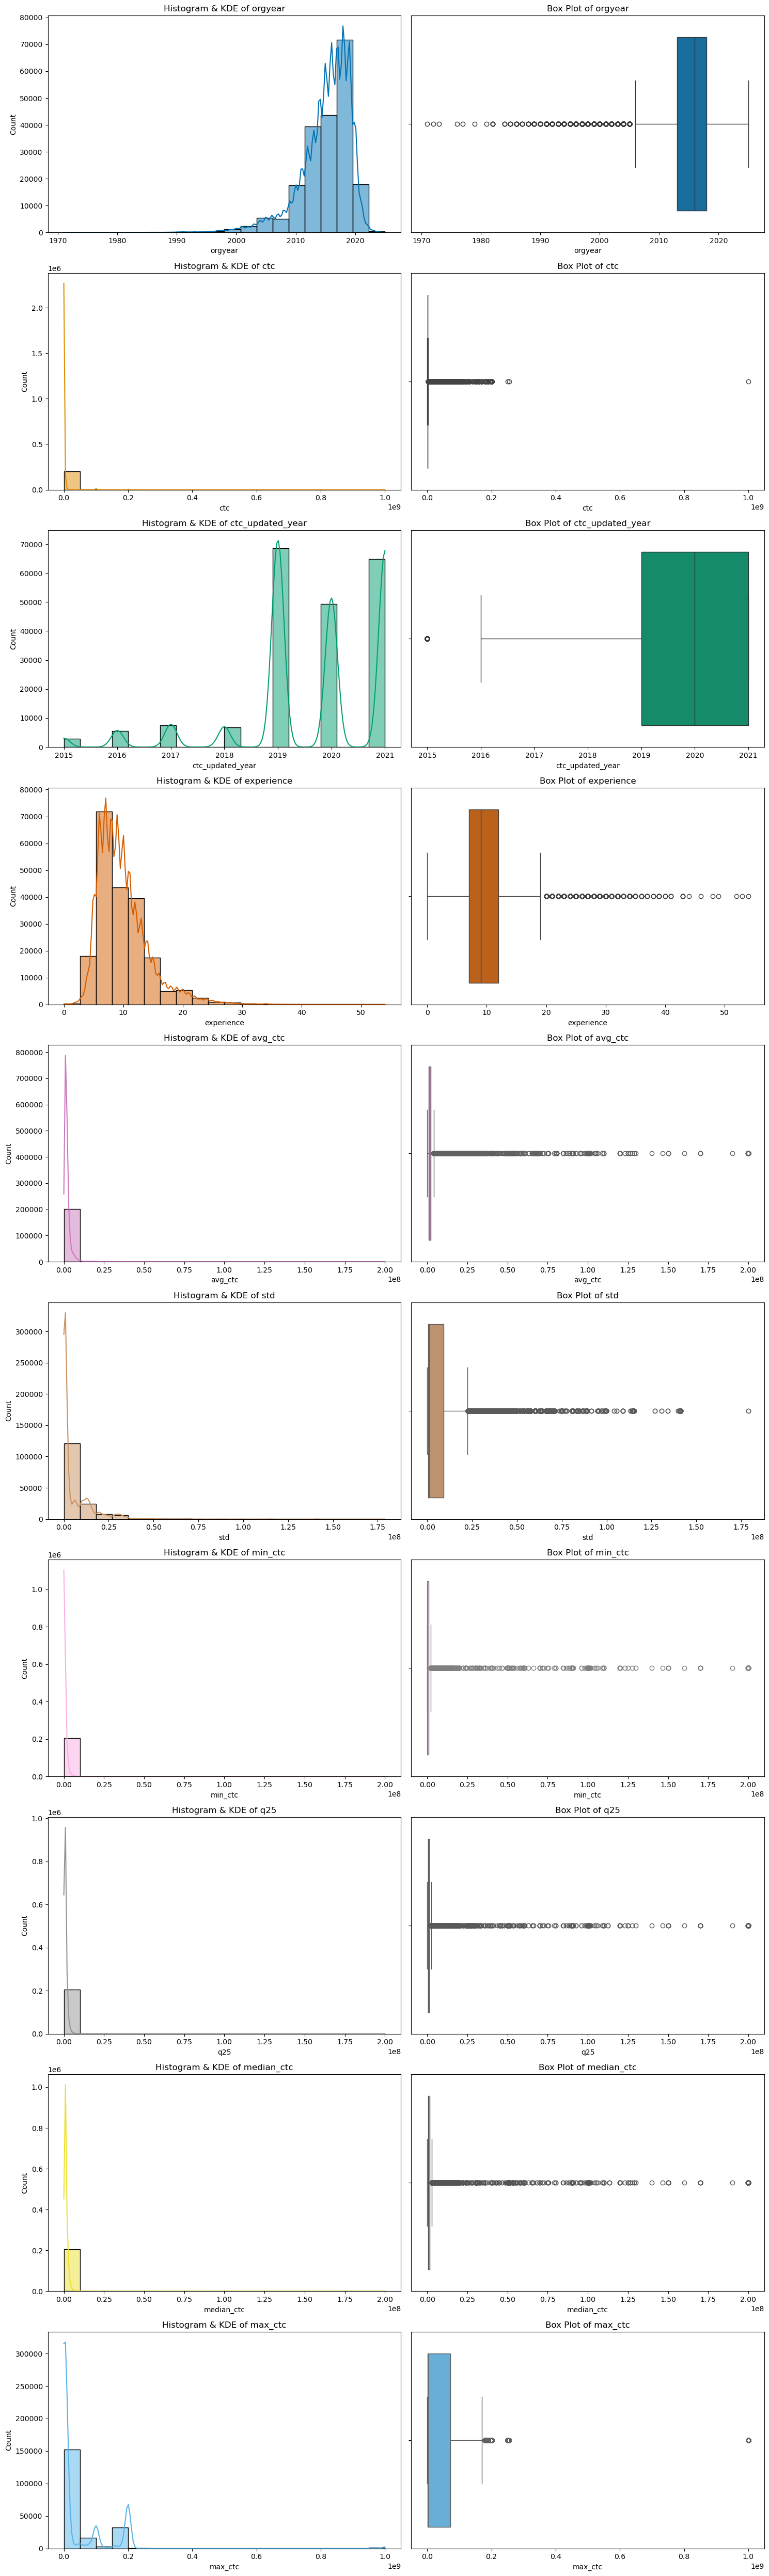

In [84]:
colors = sns.color_palette("colorblind", len(cols))

fig, axes = plt.subplots(len(cols), 2, figsize=(15, 5 * len(cols)))

for i, col in enumerate(cols):
    # Histogram + KDE
    sns.histplot(merged_df[col], bins= 20, kde=True, color=colors[i], ax=axes[i, 0])
    axes[i, 0].set_title(f"Histogram & KDE of {col}")

    # Boxplot
    sns.boxplot(x=merged_df[col], color=colors[i], ax=axes[i, 1])
    axes[i, 1].set_title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()


**Insights**:
- Clearly orgyear is very bad, it is having years in it but the data is skyrocketed
- Need more analysis on orgyear
- Huge outliers in ctc column and outliers are clearly bad for any ML algorithm, especially that one guy(he is exceptional so we can remove him)
- There are people above 50 age who wants to learn , with scaler,might be curiosity
- Most of the individuals have experience from 2 - 20 years, decreasing gradually

In [85]:
df.shape

(205472, 9)

In [86]:
# remove that one highsalry individual
df[df['ctc'] == df['ctc'].max()]

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group
72925,whmxw rgsxwo uqxcvnt rxbxnta,29a71dd13adf6d2d497571a565bb3096cf66cb46cd1ece...,2015.0,1000150000,nan,2020.0,others,10.0,non_tech


In [87]:
# he didn't entered his jobposition, neither he have something but experience of 10 years.
df= df.drop(df[df['ctc'] == df['ctc'].max()].index)

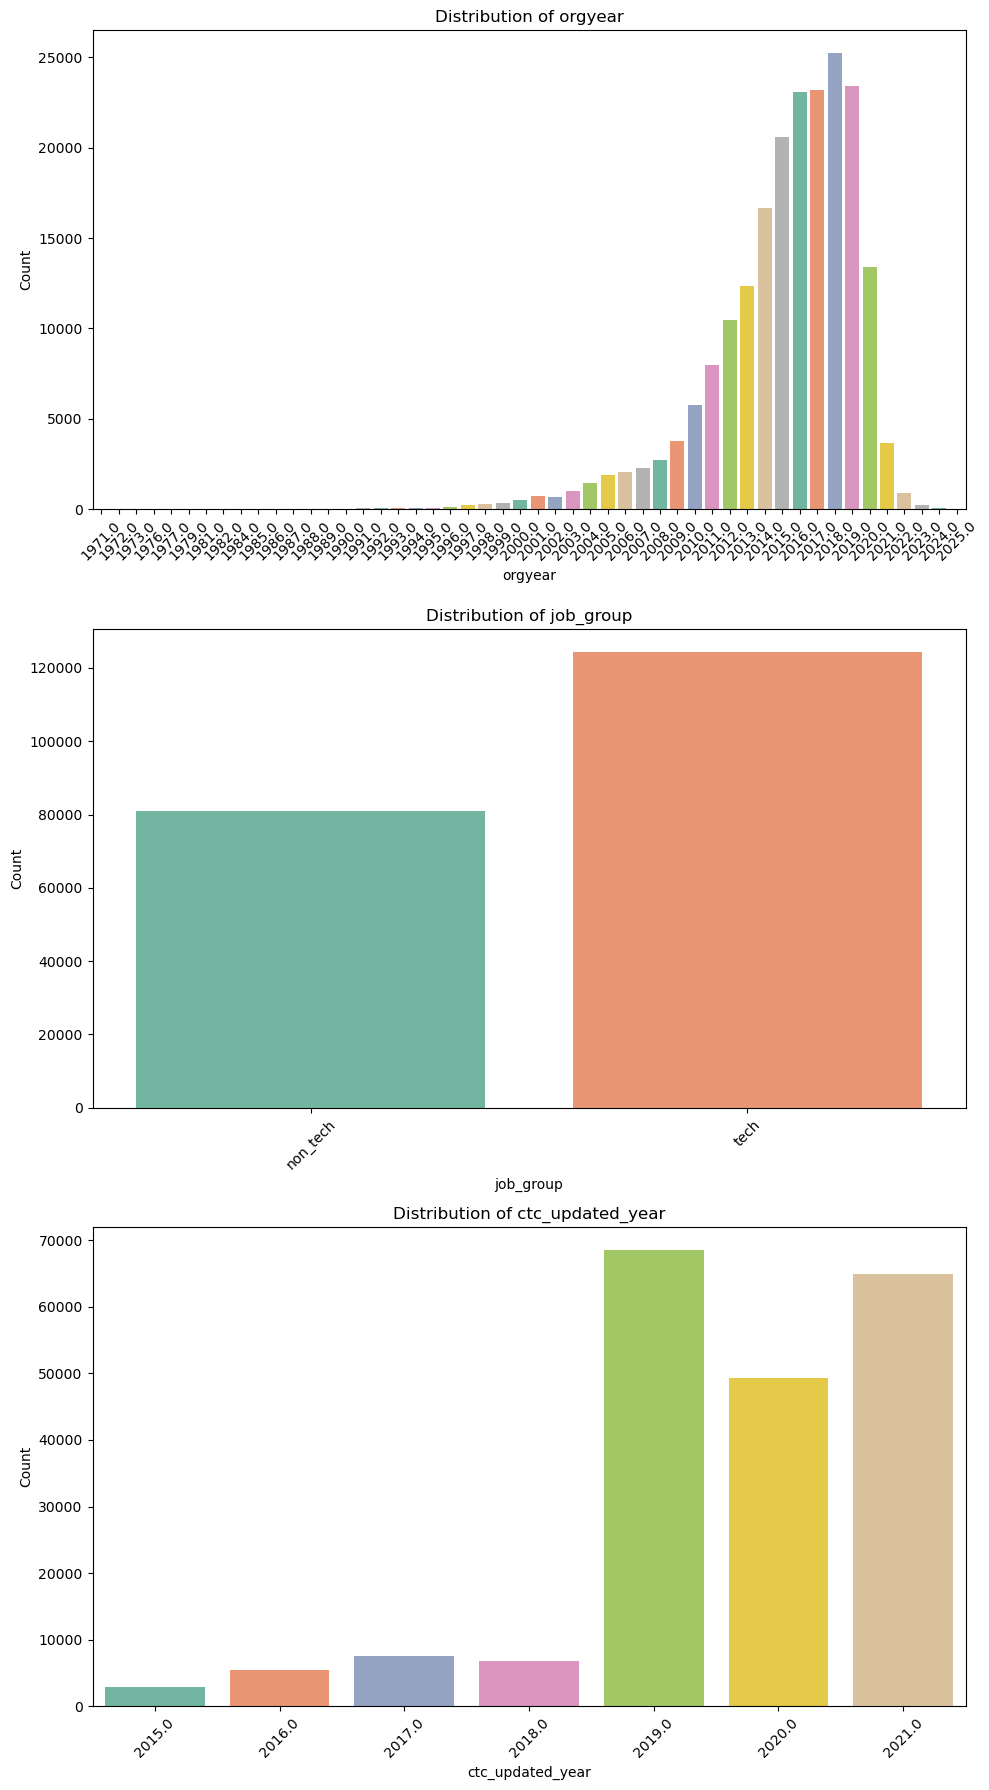

In [88]:
cat_cols= ['orgyear', 'job_group', 'ctc_updated_year']

plt.figure(figsize=(10, 18))
# for categorical data for 4 cols
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 1, i)  
    sns.countplot(x=df[col], palette="Set2")
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation= 45)
    plt.xlabel(col)
    plt.ylabel('Count')
    
plt.tight_layout()
plt.show()

#### Insights
- orgyear after cleaning abnormal years has given skewed distirbution. There are people from 1971(50 years) to 2025(1 year)
- Majority of the learners joined the company around 2016(~11) years of experience.
- Learners with tech background dominates the dataset.

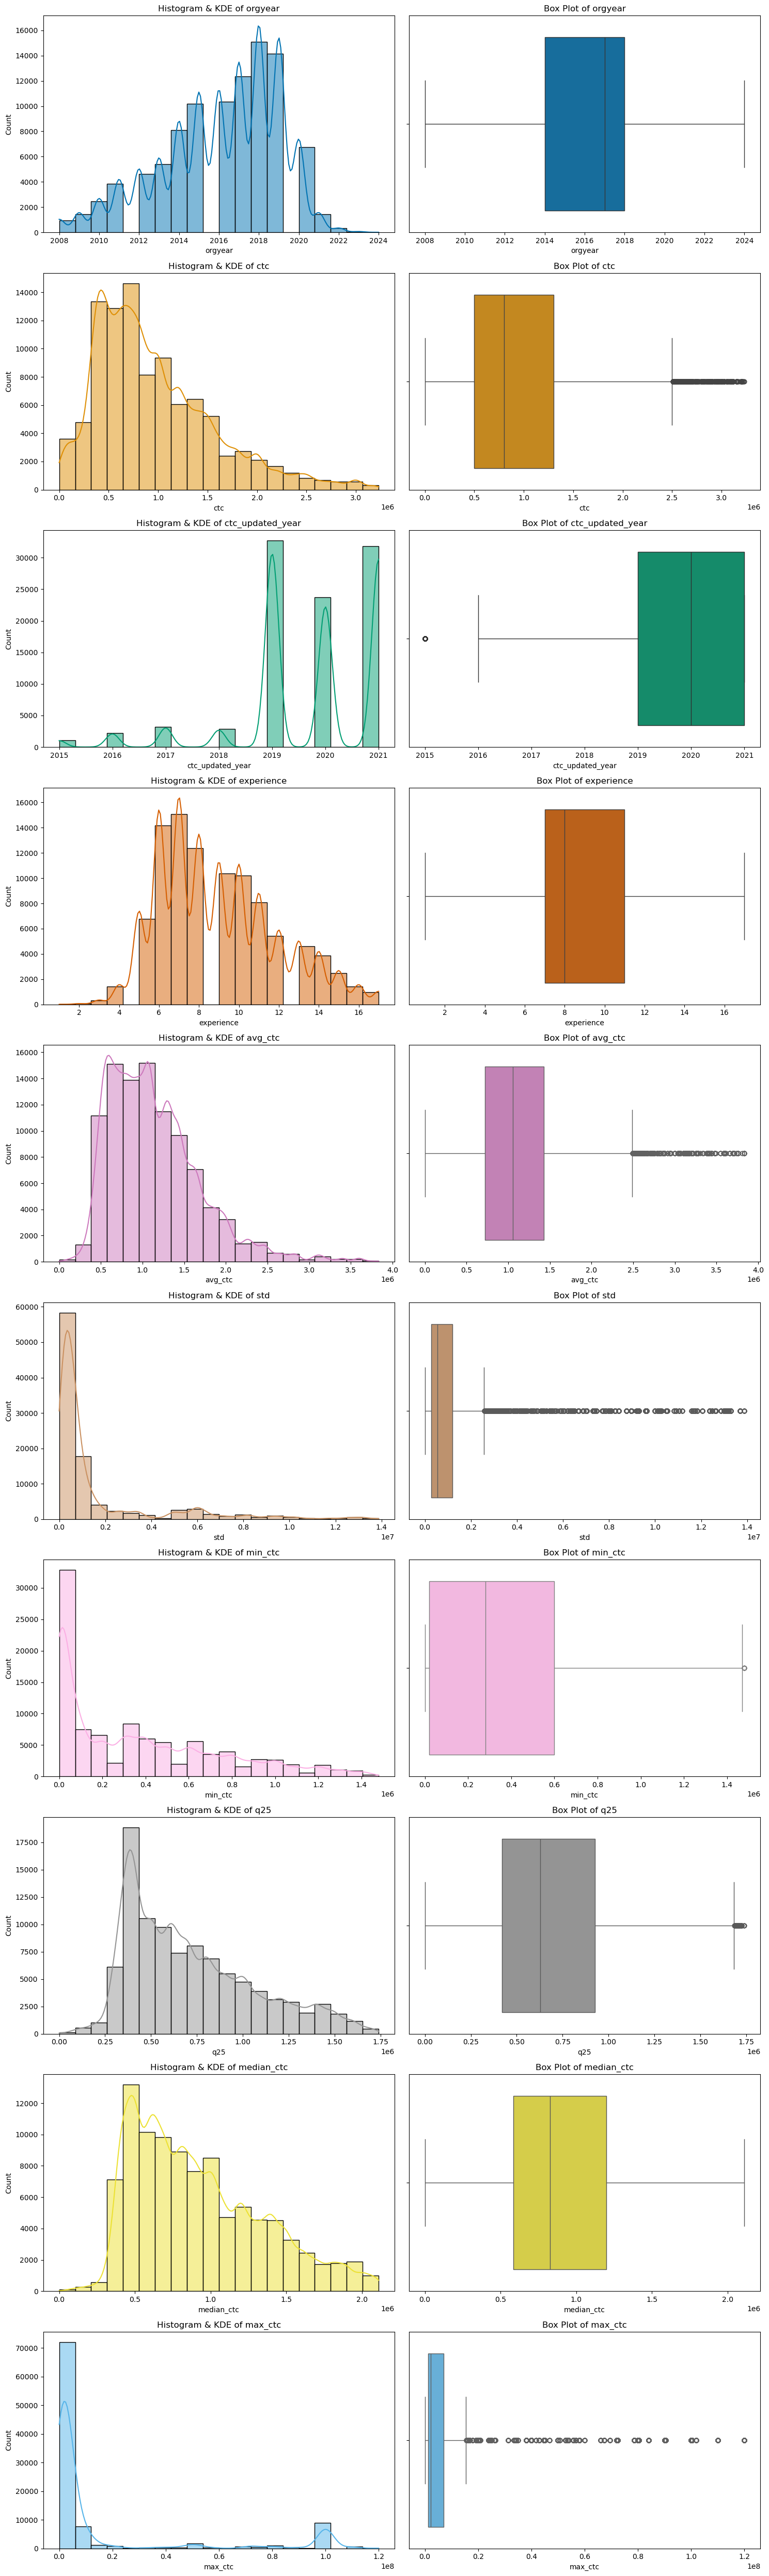

In [89]:
# AFTER CLEANING

colors = sns.color_palette("colorblind", len(cols))

fig, axes = plt.subplots(len(cols), 2, figsize=(15, 5 * len(cols)))

for i, col in enumerate(cols):
    # Histogram + KDE
    sns.histplot(cleaned_df[col], bins= 20, kde=True, color=colors[i], ax=axes[i, 0])
    axes[i, 0].set_title(f"Histogram & KDE of {col}")

    # Boxplot
    sns.boxplot(x=cleaned_df[col], color=colors[i], ax=axes[i, 1])
    axes[i, 1].set_title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()


### Bi-Variate Analysis & MultiVariate Analysis

In [90]:
df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv,9.0,non_tech
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta,7.0,tech
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others,10.0,tech
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv,8.0,tech
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu,8.0,tech


In [91]:
cleaned['ctc'].describe()

count    1.738960e+05
mean     1.872368e+06
std      6.872583e+06
min      2.000000e+00
25%      6.000000e+05
50%      1.000000e+06
75%      1.800000e+06
max      1.700000e+08
Name: ctc, dtype: float64

<Axes: xlabel='experience', ylabel='ctc'>

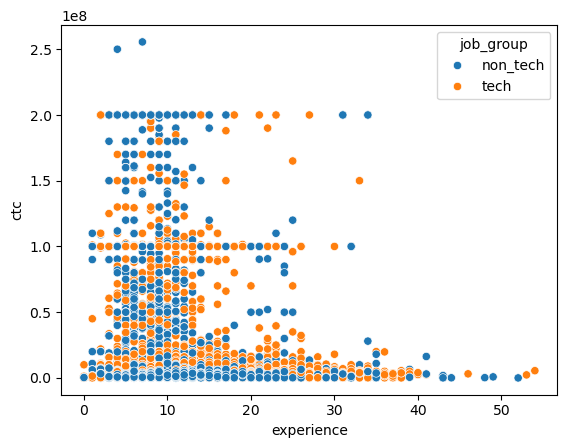

In [92]:
# Experience vs CTC
# Does salary increase with experience?
# At what point does growth plateau?
# Outliers: high salaries with low experience (fast risers) or low salaries with high experience (stagnation).

sns.scatterplot(data= df, x= "experience", y= 'ctc', hue= 'job_group')

**Suprisingly most of the young experienced ones that is 3 to 15 year earn more than the most experienced ones.**

<Axes: xlabel='orgyear', ylabel='ctc'>

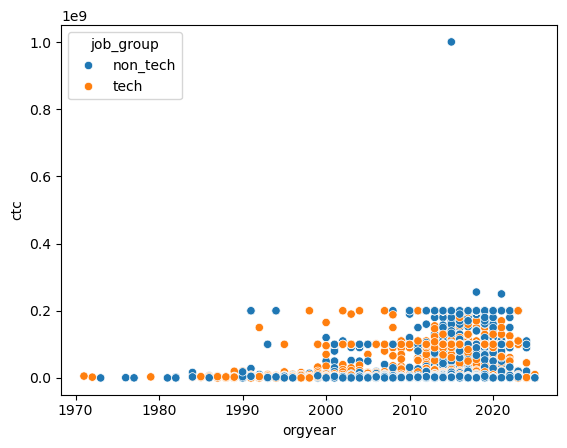

In [93]:
# Orgyear vs CTC

# Do early joiners (pre-2010) have significantly higher CTCs than recent joiners

sns.scatterplot(data= merged_df, x= "orgyear", y= 'ctc', hue= 'job_group')

- most of the individuals who has higher salaries joined in between 2010 and 2020 may be right after the 2008 crash.

# Data Preprocessing for Clustering

In [94]:
## FIRST LET'S TRY WITH OUTLIERS PRESENCE IN THE DATA

merged_df.head()

,company_hash,email_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group,count,avg_ctc,std,min_ctc,q25,median_ctc,q75,max_ctc,cluster1_d_level
0,atrgxnnt xzaxv,6de0a4417d18ab14334c3f43397fc13b30c35149d70c05...,2016.0,1100000,other,2020.0,atrgxnnt xzaxv,9.0,non_tech,1,1.100000e+06,NaN,1100000,1100000.0,1100000.0,1100000.0,1100000,2
1,qtrxvzwt xzegwgbb rxbxnta,b0aaf1ac138b53cb6e039ba2c3d6604a250d02d5145c10...,2018.0,449999,fullstack engineer,2019.0,qtrxvzwt xzegwgbb rxbxnta,7.0,tech,7,7.742856e+05,2.509223e+05,449999,610000.0,750000.0,900000.0,1200000,3
2,ojzwnvwnxw vx,4860c670bcd48fb96c02a4b0ae3608ae6fdd98176112e9...,2015.0,2000000,backend engineer,2020.0,others,10.0,tech,923,1.444876e+06,4.870455e+06,1000,500000.0,900000.0,1500000.0,100420000,1
3,ngpgutaxv,effdede7a2e7c2af664c8a31d9346385016128d66bbc58...,2017.0,700000,backend engineer,2019.0,ngpgutaxv,8.0,tech,7,1.158571e+06,4.047810e+05,700000,825000.0,1200000.0,1405000.0,1750000,3
4,qxen sqghu,6ff54e709262f55cb999a1c1db8436cb2055d8f79ab520...,2017.0,1400000,fullstack engineer,2019.0,qxen sqghu,8.0,tech,1,1.400000e+06,NaN,1400000,1400000.0,1400000.0,1400000.0,1400000,2


In [95]:
# Data processing for Unsupervised clustering - Label encoding/ One- hot encoding, Standardization of data

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Drop ID column
merged_df = merged_df.drop(columns=['email_hash'])

# Encode categorical variables (Label Encoding)
le_company = LabelEncoder()
merged_df['company_hash_updated'] = le_company.fit_transform(merged_df['company_hash_updated'])

le_jobpos = LabelEncoder()
merged_df['job_position'] = le_jobpos.fit_transform(merged_df['job_position'])

le_jobgroup = LabelEncoder()
merged_df['job_group'] = le_jobgroup.fit_transform(merged_df['job_group'])

# Select numerical columns for scaling
num_cols = ['ctc', 'experience', "std", "min_ctc","max_ctc","cluster1_d_level",
            'avg_ctc', 'avg_ctc', "q25", "median_ctc", "q75","count"]

scaler = StandardScaler()
merged_df[num_cols] = scaler.fit_transform(merged_df[num_cols])

merged_df.head()


,company_hash,orgyear,ctc,job_position,ctc_updated_year,company_hash_updated,experience,job_group,count,avg_ctc,std,min_ctc,q25,median_ctc,q75,max_ctc,cluster1_d_level
0,atrgxnnt xzaxv,2016.0,-0.099220,412,2020.0,46,-0.208776,0,-0.496248,-0.185985,NaN,0.049900,-0.022795,-0.065553,-0.118278,-0.477531,-0.372882
1,qtrxvzwt xzegwgbb rxbxnta,2018.0,-0.154334,259,2019.0,1615,-0.681388,1,-0.476180,-0.237754,-0.554694,-0.073865,-0.113907,-0.126013,-0.147069,-0.476516,1.131887
2,ojzwnvwnxw vx,2015.0,-0.022908,111,2020.0,1322,0.027530,1,2.587563,-0.131171,-0.104750,-0.159357,-0.134360,-0.100102,-0.060694,0.530534,-1.877651
3,ngpgutaxv,2017.0,-0.133136,111,2019.0,997,-0.445082,1,-0.476180,-0.176676,-0.539708,-0.026263,-0.073929,-0.048279,-0.074370,-0.470934,1.131887
4,qxen sqghu,2017.0,-0.073783,259,2019.0,1656,-0.445082,1,-0.496248,-0.138304,NaN,0.107022,0.032987,-0.013731,-0.075090,-0.474486,-0.372882


In [96]:
X = merged_df.drop(['company_hash','orgyear', 'ctc_updated_year', 'std'], axis= 1)
X.head()

,ctc,job_position,company_hash_updated,experience,job_group,count,avg_ctc,min_ctc,q25,median_ctc,q75,max_ctc,cluster1_d_level
0,-0.099220,412,46,-0.208776,0,-0.496248,-0.185985,0.049900,-0.022795,-0.065553,-0.118278,-0.477531,-0.372882
1,-0.154334,259,1615,-0.681388,1,-0.476180,-0.237754,-0.073865,-0.113907,-0.126013,-0.147069,-0.476516,1.131887
2,-0.022908,111,1322,0.027530,1,2.587563,-0.131171,-0.159357,-0.134360,-0.100102,-0.060694,0.530534,-1.877651
3,-0.133136,111,997,-0.445082,1,-0.476180,-0.176676,-0.026263,-0.073929,-0.048279,-0.074370,-0.470934,1.131887
4,-0.073783,259,1656,-0.445082,1,-0.496248,-0.138304,0.107022,0.032987,-0.013731,-0.075090,-0.474486,-0.372882


In [97]:
X.isna().sum()

ctc                     0
job_position            0
company_hash_updated    0
experience              0
job_group               0
count                   0
avg_ctc                 0
min_ctc                 0
q25                     0
median_ctc              0
q75                     0
max_ctc                 0
cluster1_d_level        0
dtype: int64

In [99]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205472 entries, 0 to 205471
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   ctc                   205472 non-null  float64
 1   job_position          205472 non-null  int64  
 2   company_hash_updated  205472 non-null  int64  
 3   experience            205472 non-null  float64
 4   job_group             205472 non-null  int64  
 5   count                 205472 non-null  float64
 6   avg_ctc               205472 non-null  float64
 7   min_ctc               205472 non-null  float64
 8   q25                   205472 non-null  float64
 9   median_ctc            205472 non-null  float64
 10  q75                   205472 non-null  float64
 11  max_ctc               205472 non-null  float64
 12  cluster1_d_level      205472 non-null  float64
dtypes: float64(10), int64(3)
memory usage: 20.4 MB


## Dimension Reductionality

### PCA: Principal Component analysis
PCA is dimension reducion technique used to compress or simplify the dataset while retaining most of its information.
1. Principal Component: An axis where data is projected and captures maximum variance in the data.
2. PCs are orthogonal(perpendicular) to each other.
3. PCAs standardize features so all contribute equally and create uncorrelated components.
4. Commonly used for dimension reduction, visuaization and speeding up machine learning models.


Explained variance ratio: [3.75022532e-01 1.63745696e-01 1.16285730e-01 7.83053676e-02
 7.12374413e-02 6.56746547e-02 4.41754395e-02 2.93527628e-02
 2.65839737e-02 2.17816892e-02 5.05395112e-03 2.68129383e-03
 9.94676528e-05]
Number of components: 13


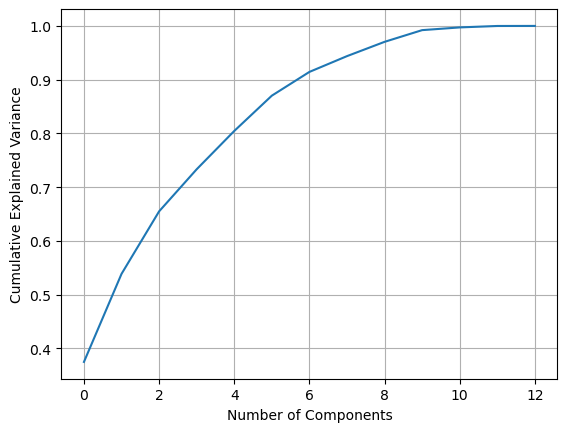

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Results
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Number of components:", pca.n_components_)

# Explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(explained_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()



In [114]:
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca_final = pca.fit_transform(X_scaled)

In [115]:
# Results
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Number of components:", pca.n_components_)

Explained variance ratio: [0.37502253 0.1637457  0.11628573 0.07830537 0.07123744 0.06567465
 0.04417544 0.02935276 0.02658397]
Number of components: 9


**We have reduced dimensions from 13 to 9 dimensions keeping the 95% of data in intact**

### tSNE: (t-Distributed Stochastic Neighbor Embedding)
- It is also a dimension reductionality technique used for visuaization high dimensional data.
- We can view the dataset even though in many dimensions in just 2D or 3D while preserving the loca simiarities between poitns
- points that are similar stay close, and disimilar are farther apart.
- is very slow but works best after PCA for faster computation and less noice but still is slow.
- perplexity define balance of local vs gloabal struture

In [117]:
# from sklearn.manifold import TSNE

# tsne= TSNE(n_components= 2, perplexity= 30, learning_rate= 200, random_state=42)
# X_tsne= tsne.fit_transform(X_pca_final)

# Takes too much time

In [ ]:
# plt.figure(figsize=(10,6))
# sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=df['cluster1_d_level'], palette='tab10')
# plt.title('t-SNE visualization')
# plt.xlabel('t-SNE 1')
# plt.ylabel('t-SNE 2')
# plt.legend(title='Cluster')
# plt.show()


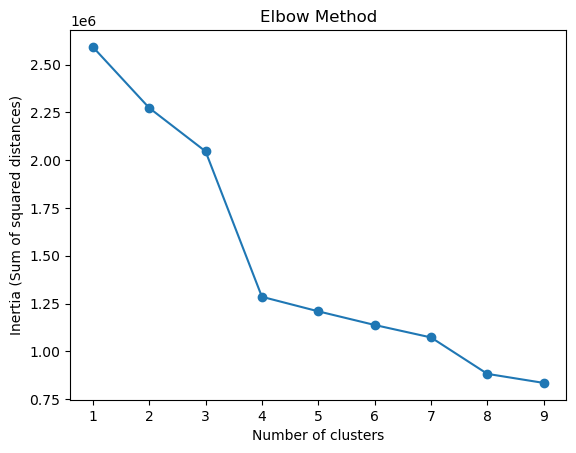

In [118]:
# 1. WCSS METHOD - SUM OF SQUARE DISTANCES
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca_final)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Method')
plt.show()


**Based on the above graph and elbow method we can choose 4 clusters**
- But before that let's try silhoutte method as well.

In [126]:
# # 2ND METHOD SILHOUTTE SCORE

# from sklearn.metrics import silhouette_score

# silhouette_scores = []
# for k in range(2, 10):
#     kmeans = KMeans(n_clusters=k, random_state=42)
#     labels = kmeans.fit_predict(X_pca_final)
#     score = silhouette_score(X_pca_final, labels)
#     silhouette_scores.append(score)

# plt.plot(range(2,10), silhouette_scores, 'o-')
# plt.xlabel('Number of clusters')
# plt.ylabel('Silhouette Score')
# plt.show()

# Takes too much time

In [127]:
# DEFINE THE CLUSTERS AND ADD THAT VARIABLE TO THE DATASET.

kmeans = KMeans(n_clusters=4, random_state=42)  #default = "k-means++"
X['cluster'] = kmeans.fit_predict(X_pca_final)

In [128]:
X.head()

,ctc,job_position,company_hash_updated,experience,job_group,count,avg_ctc,min_ctc,q25,median_ctc,q75,max_ctc,cluster1_d_level,cluster
0,-0.099220,412,46,-0.208776,0,-0.496248,-0.185985,0.049900,-0.022795,-0.065553,-0.118278,-0.477531,-0.372882,0
1,-0.154334,259,1615,-0.681388,1,-0.476180,-0.237754,-0.073865,-0.113907,-0.126013,-0.147069,-0.476516,1.131887,1
2,-0.022908,111,1322,0.027530,1,2.587563,-0.131171,-0.159357,-0.134360,-0.100102,-0.060694,0.530534,-1.877651,1
3,-0.133136,111,997,-0.445082,1,-0.476180,-0.176676,-0.026263,-0.073929,-0.048279,-0.074370,-0.470934,1.131887,1
4,-0.073783,259,1656,-0.445082,1,-0.496248,-0.138304,0.107022,0.032987,-0.013731,-0.075090,-0.474486,-0.372882,1


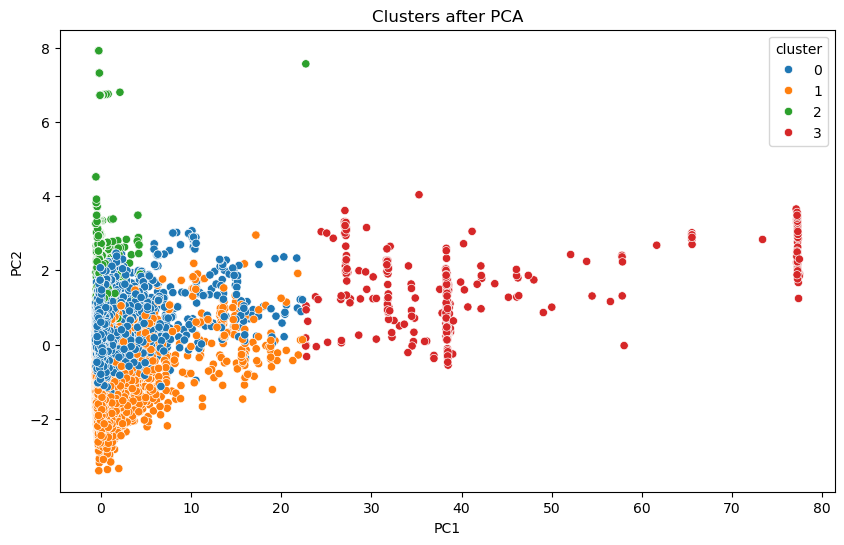

In [129]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca_final[:,0], y=X_pca_final[:,1], hue=X['cluster'], palette='tab10')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters after PCA')
plt.show()

In [130]:
X['cluster'].value_counts()

cluster
1    100281
0     73335
2     31480
3       376
Name: count, dtype: int64

In [131]:
## USING DENDOGRAM

import scipy.cluster.hierarchy as sch


plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_pca_final, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Euclidean distances')
plt.show()

MemoryError: Unable to allocate 157. GiB for an array with shape (21109268656,) and data type float64

<Figure size 1200x600 with 0 Axes>

In [134]:
## DBSCAN
from sklearn.cluster import DBSCAN
# Set parameters
dbscan = DBSCAN(eps=0.5, min_samples=5)  # tweak eps and min_samples
db_labels = dbscan.fit_predict(X_pca_final)

# Add cluster labels to your dataframe
X['dbscan_cluster'] = db_labels

In [137]:
# Number of clusters (ignoring noise)
n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print("Number of clusters found:", n_clusters)

# Cluster sizes
print(X['dbscan_cluster'].value_counts())


Number of clusters found: 473
dbscan_cluster
3      62454
0      32439
1      16164
6      15609
11     11869
       ...  
452        4
469        4
434        4
443        4
451        4
Name: count, Length: 474, dtype: int64


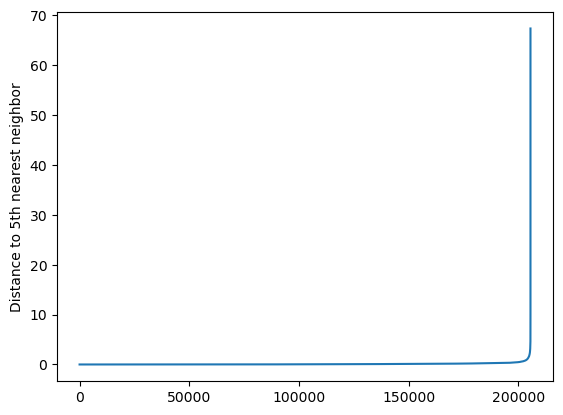

In [138]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca_final)
distances, indices = neighbors_fit.kneighbors(X_pca_final)
distances = np.sort(distances[:,4])  # 4th neighbor
plt.plot(distances)
plt.ylabel('Distance to 5th nearest neighbor')
plt.show()


# 2025 Company & Salary Dataset Insights Report

## Overview

This report provides a comprehensive analysis of the Company & Salary Dataset from Scaler School of Technology. The dataset contains 153,333 records, representing unique individuals across 36,314 companies and 1,855 job positions. The insights derived from this data offer valuable information for stakeholders, including companies, job seekers, and educational institutions.

---

## Job Group Distribution

### Key Findings:
- **Tech Roles**: 109,788 records (71.6%)
- **Non-Tech Roles**: 23,357 records (15.2%)
- **Unknown Roles**: 20,188 records (13.2%)

### Insights:
- **Tech roles dominate the dataset**, indicating a strong presence in the job market.
- **Non-Tech roles**, though fewer, show higher average salaries, suggesting specialized demand.
- **Unknown roles** constitute a significant portion, possibly due to miscategorization or emerging roles.

---

## CTC Statistics

### Summary:
- **Average CTC**: ₹2,552,644
- **Median CTC**: ₹1,000,000
- **Minimum CTC**: ₹2
- **Maximum CTC**: ₹1,000,150,000
- **25th Percentile**: ₹550,000
- **75th Percentile**: ₹1,739,999

### Insights:
- The **median CTC** is significantly lower than the average, indicating a skewed distribution due to high outliers.
- The **maximum CTC** is exceptionally high, suggesting the presence of executive-level or specialized roles.

---

## Top Job Positions by Count

### Rankings:
1. **Backend Engineer**: 33,761 people, Avg CTC ₹2,085,778
2. **Other**: 20,188 people, Avg CTC ₹4,634,615
3. **Fullstack Engineer**: 18,885 people, Avg CTC ₹1,965,273
4. **Frontend Engineer**: 8,601 people, Avg CTC ₹1,927,606

### Insights:
- **Backend Engineers** are the most common, reflecting their demand in tech.
- The **"Other" category** has the highest average CTC, possibly due to high-paying niche roles.

---

## Top Companies by Average CTC

### Rankings:
1. **whmxw rgsxwo uqxcvnt rxbxnta**: 1 person, Avg CTC ₹1,000,150,000
2. **aveegaxr xzntqzvnxgzvr hzxctqoxnj**: 1 person, Avg CTC ₹250,000,000
3. **vbvkgz wvzvav**: 1 person, Avg CTC ₹200,000,000
4. **hzxiht sqghu ge owyggro**: 1 person, Avg CTC ₹200,000,000
5. **sxo ntwyzgrgsj**: 1 person, Avg CTC ₹200,000,000

### Insights:
- The top companies likely represent high-profile or executive roles.
- These figures may be anomalies or reflect highly specialized positions.

---

## Tech vs Non-Tech Salary Comparison

### Summary:
- **Non-Tech Roles**: 23,357 people, Avg CTC ₹3,817,107
- **Tech Roles**: 109,788 people, Avg CTC ₹2,236,272
- **Unknown Roles**: 20,188 people, Avg CTC ₹2,810,211

### Insights:
- **Non-Tech roles** offer significantly higher average salaries, suggesting greater demand or specialized skills.
- **Tech roles**, while numerous, have lower average salaries, indicating competitive markets.

---

## Key Insights

1. **Highest Paying Position**: SDET/Backend Engineer (Avg ₹1,763,105)
2. **Highest Paying Company**: whmxw rgsxwo uqxcvnt rxbxnta (Avg ₹1,000,150,000)
3. **Non-Tech Roles** have higher average salaries than Tech roles.

---

## Strategic Recommendations

### For Companies:
- **Benchmark Salaries**: Use this data to ensure competitive compensation packages.
- **Talent Acquisition**: Focus on high-demand roles like Backend Engineers.
- **Analyze Outliers**: Investigate companies with exceptionally high CTCs for benchmarking.

### For Job Seekers:
- **Explore Non-Tech Roles**: Higher average salaries may offer better opportunities.
- **Skill Development**: Target high-demand roles like Backend Engineering.

### For Educational Institutions:
- **Curriculum Development**: Align programs with in-demand roles.
- **Career Counseling**: Highlight high-paying roles and industries.

---

### Conclusion

This dataset provides a snapshot of the job market, emphasizing the dominance of Tech roles and the premium on Non-Tech positions. Stakeholders can leverage these insights to make informed decisions, from talent acquisition to career planning. The presence of high outliers underscores the diversity and complexity of the market, offering opportunities for growth and innovation.

---

**"Data is the new oil. It's the resource that will drive the future."**  
— Clive Humby

Let's harness this data to fuel our strategies and success.